# Dataset

In [4]:
!pip list

Package                  Version                Editable project location
------------------------ ---------------------- -----------------------------------------------------------------
apturl                   0.5.2
asttokens                3.0.0
bcrypt                   3.2.0
blinker                  1.4
Brlapi                   0.8.3
certifi                  2020.6.20
chardet                  4.0.0
click                    8.0.3
colorama                 0.4.4
comm                     0.2.3
command-not-found        0.3
cryptography             3.4.8
cupshelpers              1.0
dbus-python              1.2.18
debugpy                  1.8.16
decorator                5.2.1
defer                    1.0.6
distro                   1.7.0
distro-info              1.1+ubuntu0.2
duplicity                0.8.21
exceptiongroup           1.3.0
executing                2.2.0
fasteners                0.14.1
filelock                 3.13.1
fsspec                   2024.6.1
future                 

In [1]:
import os
# os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
# from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import glob
import random

seed = 42


random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)  # optional
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# torch.use_deterministic_algorithms(True)
# os.environ['PYTHONHASHSEED'] = str(seed)
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False


In [2]:
# # If you want to rewrite the images. you have to delete them first.


# #!/usr/bin/env python3
# """
# Convert 3‑D ATLAS volumes (NIfTI) to 2‑D PNG slices, resized to 256×256.

# Input  (examples)
# └── /mnt/.../atlas-train-dataset-1.0.1/train/imagesTr/im0.nii.gz
# └── /mnt/.../atlas-train-dataset-1.0.1/train/labelsTr/lb0.nii.gz

# Output (examples)
# └── /mnt/.../atlas_converted/train/imagesTr/im0_0.png
# └── /mnt/.../atlas_converted/train/labelsTr/lb0_0.png
# """

# import os
# import glob
# import numpy as np
# import nibabel as nib
# import cv2

# # === EDIT HERE only if your paths differ ====================================
# IN_BASE  = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/atlas-train-dataset-1.0.1/train"
# OUT_BASE = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/atlas_converted/train"
# # =============================================================================

# def ensure_dir(path: str) -> None:
#     """Create directory (recursively) if it doesn’t exist."""
#     os.makedirs(path, exist_ok=True)

# def scale_to_uint8(img: np.ndarray) -> np.ndarray:
#     """Min–max scale a float/16‑bit slice to uint8 for PNG saving."""
#     img = img.astype(np.float32)
#     vmin, vmax = np.nanmin(img), np.nanmax(img)
#     if vmax > vmin:
#         img = (img - vmin) / (vmax - vmin) * 255.0
#     else:  # constant slice
#         img.fill(0)
#     return img.astype(np.uint8)

# def process_split(split: str) -> None:
#     """
#     split = "imagesTr" or "labelsTr"
#     """
#     in_dir  = os.path.join(IN_BASE, split)
#     out_dir = os.path.join(OUT_BASE, split)
#     ensure_dir(out_dir)

#     nii_paths = sorted(glob.glob(os.path.join(in_dir, "*.nii.gz")))
#     if not nii_paths:
#         print(f"[WARN] No .nii.gz files found in {in_dir}")
#         return

#     for nii_path in nii_paths:
#         # vol_name   = os.path.splitext(os.path.basename(nii_path))[0]  # im0 / lb0
#         base_name = os.path.basename(nii_path)
#         vol_name  = base_name.replace(".nii.gz", "").replace(".nii", "")
#         # print(f"[INFO] ⇢  {vol_name}  …", flush=True)


#         # Load volume (shape: W × H × S)
#         vol = nib.load(nii_path).get_fdata()

#         # Iterate over axial slices
#         for z in range(vol.shape[2]):
#             slice_img = vol[..., z]  # 2‑D numpy array


#             if split == "imagesTr":
#                 slice_img = cv2.resize(slice_img, (256, 256), interpolation=cv2.INTER_LINEAR)
#                 slice_img = scale_to_uint8(slice_img)
#             else:  # labelsTr
#                 slice_img = cv2.resize(slice_img, (256, 256), interpolation=cv2.INTER_NEAREST)
#                 # slice_img = slice_img.astype(np.uint8)        
#                 slice_img = np.rint(slice_img).astype(np.uint8)

#             # Save
#             png_fname = f"{vol_name}_{z}.png"
#             png_path  = os.path.join(out_dir, png_fname)
#             cv2.imwrite(png_path, slice_img)

# if __name__ == "__main__":
#     # Make sure the outer converted directories exist:
#     ensure_dir(os.path.join(OUT_BASE, "imagesTr"))
#     ensure_dir(os.path.join(OUT_BASE, "labelsTr"))

#     process_split("imagesTr")
#     process_split("labelsTr")

#     print("\n✅ Conversion finished.")




Unique label values: [0 1]


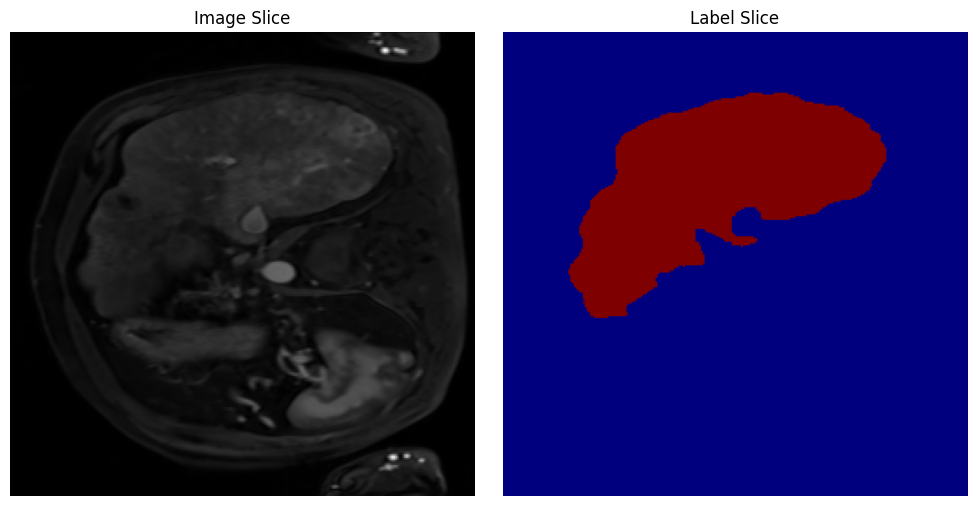

In [3]:

# Paths to the image and label PNGs
image_path = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Atlas_dataset/leftImg8bit/train/im0_44.png"
label_path = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Atlas_dataset/gtFine/train/lb0_44.png"

# Load using cv2.IMREAD_UNCHANGED to preserve exact data
image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
label = cv2.imread(label_path, cv2.IMREAD_UNCHANGED)
# print(np.unique(image))
# Print unique pixel values in the label image
unique_values = np.unique(label)
print("Unique label values:", unique_values)

# Plot side-by-side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Image Slice")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Label Slice")
plt.imshow(label, cmap='jet')  # use color map to distinguish label regions
plt.axis('off')

plt.tight_layout()
plt.show()


In [4]:
# Path to label slices
label_dir = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/atlas_converted/train/labelsTr"

# Get all PNG files
label_paths = sorted(glob.glob(os.path.join(label_dir, "*.png")))
print(len(label_paths))

blank_count = 0

for path in label_paths:
    label = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    unique_vals = np.unique(label)
    if len(unique_vals) == 1 and unique_vals[0] == 0:
        blank_count += 1

print("Number of blank label slices:", blank_count)


4744
Number of blank label slices: 985


In [5]:

# from sklearn.model_selection import train_test_split   # kept for naming consistency

ROOT_DIR   = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/atlas_converted/train"
IMG_DIR    = os.path.join(ROOT_DIR, "imagesTr")
LABEL_DIR  = os.path.join(ROOT_DIR, "labelsTr")

def collect_pairs(img_dir: str, lbl_dir: str):
    X, Y = [], []
    img_paths = sorted(glob.glob(os.path.join(img_dir, "im*.png")))
    for img_path in img_paths:
        fname      = os.path.basename(img_path)       # e.g. im12_7.png
        lbl_fname  = "lb" + fname[2:]
        lbl_path   = os.path.join(lbl_dir, lbl_fname)
        if os.path.exists(lbl_path):
            X.append(img_path)
            Y.append(lbl_path)
    return X, Y

image_paths, mask_paths = collect_pairs(IMG_DIR, LABEL_DIR)
print(f"Paired slices found: {len(image_paths)}")

X_train, X_val, Y_train, Y_val = [], [], [], []

for img_path, lbl_path in zip(image_paths, mask_paths):
    fname   = os.path.basename(img_path)          # im12_7.png
    vol_id  = int(fname.split('_')[0][2:])        # 'im12' -> 12
    if vol_id < 48:                               # first 48 volumes → train
        X_train.append(img_path)
        Y_train.append(lbl_path)
    else:                                         # last 12 volumes → valid
        X_val.append(img_path)
        Y_val.append(lbl_path)

print(f"Train images: {len(X_train)},  validation images: {len(X_val)}")


Paired slices found: 4744
Train images: 3820,  validation images: 924


In [6]:
# import os
# import glob
# from sklearn.model_selection import train_test_split

# # ------------------------------------------------------------------
# # Adjust this if your converted data lives elsewhere
# ROOT_DIR   = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/atlas_converted/train"
# IMG_DIR    = os.path.join(ROOT_DIR, "imagesTr")   # .../imagesTr
# LABEL_DIR  = os.path.join(ROOT_DIR, "labelsTr")   # .../labelsTr
# # ------------------------------------------------------------------

# def collect_pairs(img_dir: str, lbl_dir: str):
#     """
#     Build two aligned lists (images, labels).
#     Assumes filenames like  im0_23.png  ↔  lb0_23.png
#     """
#     X, Y = [], []

#     # Grab every image file whose name starts with 'im'
#     img_paths = sorted(glob.glob(os.path.join(img_dir, "im*.png")))

#     for img_path in img_paths:
#         fname = os.path.basename(img_path)          # e.g. 'im0_23.png'
#         lbl_fname = "lb" + fname[2:]                # 'lb0_23.png'
#         lbl_path  = os.path.join(lbl_dir, lbl_fname)

#         if os.path.exists(lbl_path):                # keep only perfect pairs
#             X.append(img_path)
#             Y.append(lbl_path)
#         else:
#             print(f"[WARN] Label not found for {fname}")

#     return X, Y

# # ------------------------------------------------------------------
# # 1) Collect paired file paths
# # ------------------------------------------------------------------
# image_paths, mask_paths = collect_pairs(IMG_DIR, LABEL_DIR)

# print(f"Paired slices found: {len(image_paths)}")

# # ------------------------------------------------------------------
# # 2) Train / validation split  (80 % / 20 %, reproducible)
# # ------------------------------------------------------------------
# X_train, X_val, Y_train, Y_val = train_test_split(
#     image_paths,
#     mask_paths,
#     test_size=0.20,
#     random_state=42,
#     shuffle=True
# )

# print(f"Train images: {len(X_train)},  validation images: {len(X_val)}")


In [7]:
# import cv2
# import numpy as np

# def count_blank_labels(label_paths):
#     count = 0
#     for path in label_paths:
#         label = cv2.imread(path, cv2.IMREAD_UNCHANGED)
#         if label is not None and np.unique(label).tolist() == [0]:
#             count += 1
#     return count

# # Count blank slices in train and validation labels
# blank_train = count_blank_labels(Y_train)
# blank_val = count_blank_labels(Y_val)

# print(f"Blank training masks: {blank_train}")
# print(f"Blank validation masks: {blank_val}")


In [8]:
print(X_train[0])

/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/atlas_converted/train/imagesTr/im0_0.png


In [9]:
# import os
# import cv2
# import numpy as np

# # Define the output folder where the new structure will be created
# output_folder = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Atlas_dataset"

# # Define target folders
# leftImg8bit_train = os.path.join(output_folder, "leftImg8bit/train")
# leftImg8bit_val   = os.path.join(output_folder, "leftImg8bit/val")
# gtFine_train      = os.path.join(output_folder, "gtFine/train")
# gtFine_val        = os.path.join(output_folder, "gtFine/val")

# # Create folders if they don't exist
# os.makedirs(leftImg8bit_train, exist_ok=True)
# os.makedirs(leftImg8bit_val, exist_ok=True)
# os.makedirs(gtFine_train, exist_ok=True)
# os.makedirs(gtFine_val, exist_ok=True)

# # Function to copy slices with cv2.IMREAD_UNCHANGED
# def copy_slices(image_paths, label_paths, image_dest, label_dest):
#     for img_path, lbl_path in zip(image_paths, label_paths):
#         # Read the images using cv2.IMREAD_UNCHANGED
#         img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
#         lbl = cv2.imread(lbl_path, cv2.IMREAD_UNCHANGED)
        
        
#         # lbl = np.where(lbl == 2, 1, 0)   # to convert into tumor and no tumor slices.
        
#         lbl = np.where(lbl == 0, 0, 1)   # converting liver and tumor slices into liver.


#         # Prepare destination file names
#         img_name = os.path.basename(img_path)
#         lbl_name = os.path.basename(lbl_path)

#         # Save to respective destination folders
#         cv2.imwrite(os.path.join(image_dest, img_name), img)
#         cv2.imwrite(os.path.join(label_dest, lbl_name), lbl)

# # Copy training data
# copy_slices(X_train, Y_train, leftImg8bit_train, gtFine_train)

# # Copy validation data
# copy_slices(X_val, Y_val, leftImg8bit_val, gtFine_val)

# print("✅ Slices copied into structured folders.")


In [10]:


# Load the image
image_path = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Atlas_dataset/gtFine/val/lb54_51.png"
image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)  # Load in original format

# Print the shape
print("Image shape:", image.shape)

# Check if the image is grayscale or RGB
if len(image.shape) == 2:  # Grayscale image
    print("The image is grayscale.")
    unique_values = np.unique(image)
    print("Unique pixel values:", unique_values)
    
elif len(image.shape) == 3 and image.shape[2] == 3:  # RGB image
    print("The image is RGB.")
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB
    unique_colors = np.unique(image_rgb.reshape(-1, 3), axis=0)
    print("Unique colors in the image:", unique_colors)
else:
    print("Unknown image format.")



Image shape: (256, 256)
The image is grayscale.
Unique pixel values: [0 1]


# Data Loader

In [11]:
import json
from PIL import Image
from torch.utils.data import Dataset
import torchvision.transforms.functional as F
from detectron2.structures import Instances, BitMasks, Boxes
from torchvision.transforms import functional as TF

In [12]:
# def rgb2id(color):
#     """ Pass the image from RGB to the instance id value
#     See COCO format doc https://cocodataset.org/#format-data
#     """
#     if isinstance(color, np.ndarray) and len(color.shape) == 3:
#         if color.dtype == np.uint8:
#             color = color.astype(np.int32)
#         return color[:, :, 0] + 256 * color[:, :, 1] + 256 * 256 * color[:, :, 2]
#     return int(color[0] + 256 * color[1] + 256 * 256 * color[2])


# def coco_to_pascal_bbox(bbox):
#     return np.stack((bbox[:,0], bbox[:,1],
#             bbox[:,0]+bbox[:,2], bbox[:,1]+bbox[:,3]), axis=1)


# def collate_fn(inputs):
#     return {
#         'image': torch.stack([TF.to_tensor(i['image']) for i in inputs]),
#         'semantic': torch.as_tensor([i['semantic'] for i in inputs]),
#         'instance': [i['instance'] for i in inputs],
#         'image_id': [i['image_id'] for i in inputs]
#     }

def collate_fn(batch):
    def to_tensor(img):
        if isinstance(img, torch.Tensor):
            return img  # already tensor
        elif img.ndim == 2:
            return torch.from_numpy(img).unsqueeze(0)
        else:
            return torch.from_numpy(img).permute(2, 0, 1)
    images   = [to_tensor(sample["image"]).float()   for sample in batch]
    semantics = [torch.from_numpy(sample["semantic"]).long()
                 for sample in batch]

    return {
        "image":    torch.stack(images),      # B × C × H × W
        "semantic": torch.stack(semantics)    # B × H × W
    }  

In [13]:
# import sys
# print(sys.path)

# Config

In [14]:
import logging
import albumentations as A
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)
from detectron2.config import get_cfg, CfgNode
from detectron2.utils.events import _CURRENT_STORAGE_STACK, EventStorage
import sys
# from EfficientPS.datasets.panoptic_dataset import PanopticDataset, collate_fn

/home/miglab/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
def add_custom_param(cfg):
    """
    In order to add custom config parameter in the .yaml those parameter must
    be initialised
    """
    # Model
    cfg.MODEL_CUSTOM = CfgNode()
    cfg.MODEL_CUSTOM.BACKBONE = CfgNode()
    cfg.MODEL_CUSTOM.BACKBONE.EFFICIENTNET_ID = 7
    cfg.MODEL_CUSTOM.BACKBONE.LOAD_PRETRAIN = True
    # DATASET
    cfg.NUM_CLASS = 2
    cfg.DATASET_PATH = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Atlas_dataset"
    cfg.TRAIN_JSON = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Liver_dataset/output/cityscapes_panoptic_train.json"
    cfg.VALID_JSON = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Liver_dataset/output/cityscapes_panoptic_val.json"
    cfg.PRED_DIR = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Liver_dataset/preds"
    cfg.PRED_JSON = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Liver_dataset/preds/cityscapes_panoptic_preds.json"
    # Transfom
    cfg.TRANSFORM = CfgNode()
    cfg.TRANSFORM.NORMALIZE = CfgNode()
    cfg.TRANSFORM.NORMALIZE.MEAN = (0.5,)
    cfg.TRANSFORM.NORMALIZE.STD  = (0.5,)
    cfg.TRANSFORM.RESIZE = CfgNode()
    cfg.TRANSFORM.RESIZE.HEIGHT = 256
    cfg.TRANSFORM.RESIZE.WIDTH = 256
    cfg.TRANSFORM.RANDOMCROP = CfgNode()
    cfg.TRANSFORM.RANDOMCROP.HEIGHT = 256
    cfg.TRANSFORM.RANDOMCROP.WIDTH = 256
    cfg.TRANSFORM.HFLIP = CfgNode()
    cfg.TRANSFORM.HFLIP.PROB = 0.5
    # Solver
    cfg.SOLVER.NAME = "AdamW"
    cfg.SOLVER.ACCUMULATE_GRAD = 1
    cfg.SOLVER.MAX_EPOCHS = 100
    # Runner
    cfg.BATCH_SIZE = 8
    cfg.CHECKPOINT_PATH = ""
    cfg.PRECISION = 32
    # Callbacks
    cfg.CALLBACKS = CfgNode()
    cfg.CALLBACKS.CHECKPOINT_DIR = None
    # Inference
    cfg.INFERENCE = CfgNode()
    cfg.INFERENCE.AREA_TRESH = 0


In [ ]:

# class PanopticcDataset(Dataset):
#     """A dataset for Panotic task"""

#     def __init__(self, path_json, root_dir, split, transform=None):
#         """
#         Args:
#             csv_file (string): Path to the csv file with annotations.
#             root_dir (string): Directory with all the images.
#             transform (callable, optional): Optional transform to be applied
#                 on a sample.
#         """
#         self.root_dir = root_dir
#         self.split = split
#         self.transform = transform
#         # Load json file containing information about the dataset
#         path_file = os.path.join(self.root_dir, path_json)
#         data = json.load(open(path_file)) 

#         annotations = data['annotations']
#         images = data['images']
#         self.categories = data['categories']
#         # print(self.categories)
#         # raise Exception
#         # TOiDO Possible problem with VOID label and train_id
#         # Add mapper to training id and class id
#         self.semantic_class_mapper = {cat['id']:{
#                                         'train_id':i,
#                                         'isthing': cat['isthing']
#                                     }
#                                     for i, cat in enumerate(self.categories)}
#         # print(self.semantic_class_mapper)
#         self.instance_class_mapper = {cat['id']:{
#                                         'train_id':i
#                                     }
#                                     for i, cat in enumerate(self.categories[1:])}
#         # print(self.instance_class_mapper)

#         self.semantic_class_mapper.update({0:{
#                         'train_id':len(self.categories) +1,
#                         'isthing':0 }})
#         # print(self.semantic_class_mapper)
#         self.semantic_train_id_to_eval_id = [1, 2, 0]
#         self.instance_train_id_to_eval_id = [2]

#         # Generate a dictionary with all needed information with idx as key
#         self.meta_data = {}
#         for i in range(len(images)):
#             self.meta_data.update({i:{}})
#             #TODiO Error Message
#             assert annotations[i]['image_id'] == images[i]['id']
#             self.meta_data[i].update({'labelfile_name': annotations[i]['file_name']})
#             self.meta_data[i].update(annotations[i])
#             self.meta_data[i].update(images[i])
#         # print("Hello world")

#     def __len__(self):
#         return len(self.meta_data)

#     def __getitem__(self, idx):
#         # Retrieve meta data of image
#         img_data = self.meta_data[idx]
#         # print(img_data['file_name'])
#         # Load image
#         path_img = os.path.join(self.root_dir,
#                                 'leftImg8bit',
#                                 self.split,
#                                 img_data['file_name'].replace('gtFine_', ''))
#         image = np.asarray(Image.open(path_img))

        
#         # Get label info
#         path_label = os.path.join(self.root_dir,
#                                   'output',
#                                   'cityscapes_panoptic_'+self.split,
#                                   img_data['labelfile_name'])
        
#         panoptic = np.asarray(Image.open(path_label))
    

#         panoptic = rgb2id(panoptic)
#         # print(np.unique(panoptic))
#         # raise Exception
#         # Get bbox info
#         rpn_bbox = []
#         class_bbox = []
#         for seg in img_data['segments_info']:
#             seg_category = self.semantic_class_mapper[seg['category_id']]
#             if seg_category['isthing']:
#                 rpn_bbox.append(seg["bbox"])
#                 class_bbox.append(self.instance_class_mapper[seg['category_id']])
#         class_bbox = [item['train_id'] for item in class_bbox]  

#         # if len(rpn_bbox) > 0:
#         #     print(rpn_bbox)
#         #     bbox = rpn_bbox[0]
            
#         #     # Load image and make it writable
#         #     panoptic = np.asarray(Image.open(path_label)).copy()  # Ensure it's writable

#         #     # Draw bounding box
#         #     cv2.rectangle(panoptic, 
#         #                 (bbox[0], bbox[1]), 
#         #                 (bbox[0] + bbox[2] - 1, bbox[1] + bbox[3] - 1), 
#         #                 (0, 255, 0), 2)

#         #     # Display image
#         #     plt.imshow(panoptic)
#         #     plt.axis("off")  # Hide axis for better visualization
#         #     plt.show()

#         #     raise Exception


        
#         # Apply augmentation with albumentations
#         if self.transform is not None:
#             transformed = self.transform(
#                 image=image,
#                 mask=panoptic,
#                 bboxes=rpn_bbox,
#                 class_labels=class_bbox
#             )
#             image = transformed['image']
#             panoptic = transformed['mask']
#             rpn_bbox = transformed['bboxes']
#             class_bbox = transformed['class_labels']
        
#         # Create instance class for detectron (Mask RCNN Head)
#         instance = Instances(panoptic.shape)

#         # Create semantic segmentation target with augmented data
#         semantic = np.zeros_like(panoptic, dtype=np.int64)
#         rpn_mask = np.zeros_like(panoptic)
#         instance_mask = []
#         instance_cls = []

#         for seg in img_data['segments_info']:
#             seg_category = self.semantic_class_mapper[seg['category_id']]
#             semantic[panoptic == seg["id"]] = seg_category['train_id']
#             # If segmentation is a thing generate a mask for maskrcnn target
#             # Collect information for RPN targets
#             if seg_category['isthing']:
#                 seg_category = self.instance_class_mapper[seg['category_id']]
#                 mask = np.zeros_like(panoptic)
#                 mask[panoptic == seg["id"]] = 1 #seg_category['train_id']
#                 instance_cls.append(seg_category['train_id'])
#                 instance_mask.append(mask)
#                 # RPN targets
#                 rpn_mask[panoptic == seg["id"]] = 1

#         # Create same size of bbox and mask instance
#         if len(rpn_bbox) > 0:
#             rpn_bbox = coco_to_pascal_bbox(np.stack([*rpn_bbox]))

#             instance.gt_masks = BitMasks(instance_mask)
#             instance.gt_classes = torch.as_tensor(instance_cls)
#             instance.gt_boxes = Boxes(rpn_bbox)
#         else:
#             instance.gt_masks = BitMasks(torch.Tensor([]).view(0,1,1))
#             instance.gt_classes = torch.as_tensor([])
#             instance.gt_boxes = Boxes([])
            
#         return {
#             'image': np.array(image),
#             'semantic': semantic,
#             'instance': instance,
#             'image_id': img_data['image_id']
#         }


# Original Dataset Class


# class PanopticcDataset(Dataset):
#     """
#     Minimal dataset for the converted ATLAS liver slices.
#     Expects the structure:

#       <root_dir>/
#         ├── leftImg8bit/<split>/   im0_0.png …
#         └── gtFine/<split>/        lb0_0.png …

#     Each image file "im*.png" must have a matching label "lb*.png"
#     with identical suffix (e.g. im0_23.png ↔ lb0_23.png).
#     """

#     def __init__(self, path_json, root_dir, split, transform=None):
#         """
#         Args:
#             path_json (str):   Ignored (kept for API compatibility).
#             root_dir  (str):   Atlas_dataset directory.
#             split     (str):   "train" or "val".
#             transform (callable, optional):
#                 Albumentations / torchvision style transform
#                 that accepts  image=…, mask=…  and returns same keys.
#         """
#         self.root_dir  = root_dir
#         self.split     = split
#         self.transform = transform

#         img_dir  = os.path.join(root_dir, "leftImg8bit", split)
#         lbl_dir  = os.path.join(root_dir, "gtFine",     split)

#         if not (os.path.isdir(img_dir) and os.path.isdir(lbl_dir)):
#             raise FileNotFoundError(f"Expected {img_dir} and {lbl_dir}")

#         # Gather & pair files
#         self.image_paths, self.label_paths = self._collect_pairs(img_dir, lbl_dir)
#         if len(self.image_paths) == 0:
#             raise RuntimeError(f"No paired slices found in {img_dir}")

#     @staticmethod
#     def _collect_pairs(img_dir, lbl_dir):
#         """Return two aligned lists of image and label paths."""
#         imgs = sorted(glob.glob(os.path.join(img_dir, "im*.png")))
#         images, labels = [], []
#         for img_path in imgs:
#             base = os.path.basename(img_path)          # im0_23.png
#             lbl_name = "lb" + base[2:]                 # lb0_23.png
#             lbl_path = os.path.join(lbl_dir, lbl_name)
#             if os.path.exists(lbl_path):
#                 images.append(img_path)
#                 labels.append(lbl_path)
#             else:
#                 # You can log a warning here if desired
#                 pass
#         return images, labels

#     def __len__(self):
#         return len(self.image_paths)

#     def __getitem__(self, idx):
#         # --- read slice + mask (unchanged) -----------------------------
#         img_path  = self.image_paths[idx]
#         lbl_path  = self.label_paths[idx]

#         image     = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)  # H×W, uint8
#         semantic  = cv2.imread(lbl_path, cv2.IMREAD_UNCHANGED)  # H×W, uint8

#         if image is None or semantic is None:
#             raise RuntimeError(f"Failed to load {img_path} or {lbl_path}")

#         # --- optional augment / resize --------------------------------
        
#         if self.transform is not None:
#             # image_pil = Image.fromarray(image, mode='L')
#             # image = self.transform(image_pil)  # result is a torch.Tensor
#             transformed = self.transform(image=image, mask=semantic, seed=42)
#             image = transformed["image"]
#             semantic = transformed["mask"]

#             # image = image_tensor.numpy()
            
#         # if self.transform is not None:
#         #     if isinstance(self.transform, A.ReplayCompose):
#         #         transformed = self.transform(image=image, mask=semantic)
#         #         # If you want to apply the exact same transform again:
#         #         transformed = A.ReplayCompose.replay(transformed['replay'], image=image, mask=semantic)
#         #     else:
#         #         transformed = self.transform(image=image, mask=semantic)

#             # image = transformed["image"]
#             # semantic = transformed["mask"]

#         # --- return ----------------------------------------------------
#         return {
#             "image":    image,     # keep as NumPy array or convert to torch tensor here
#             "semantic": semantic   # values 0 / 1 / 2 unchanged
#         }


# from torch.utils.data import Dataset
# from PIL import Image
# import torch

# class PanopticcDataset(Dataset):
#     """
#     Minimal dataset class that now takes pre-loaded image/label data lists.
#     """

#     def __init__(self, image_list, label_list, transform=None):
#         """
#         Args:
#             image_list (List[np.ndarray]): List of image arrays.
#             label_list (List[np.ndarray]): List of label arrays.
#             transform (callable, optional): Transform to apply (e.g. torchvision).
#         """
#         self.image_data = image_list
#         self.label_data = label_list
#         self.transform = transform

#         if len(self.image_data) != len(self.label_data):
#             raise ValueError("Image and label list lengths do not match.")

#     def __len__(self):
#         return len(self.image_data)

#     def __getitem__(self, idx):
#         image = self.image_data[idx]
#         semantic = self.label_data[idx]

#         if image is None or semantic is None:
#             raise RuntimeError(f"Failed to load image or label at index {idx}")

#         # --- optional transform ----------------------------------------
#         # if self.transform is not None:
#         #     image_pil = Image.fromarray(image, mode='L')
#         #     image = self.transform(image_pil)  # returns torch.Tensor
#         #     # semantic remains as NumPy (or you can also convert it to torch.Tensor here)

#         if self.transform is not None:
#             # image_pil = Image.fromarray(image, mode='L')
#             # image = self.transform(image_pil)  # result is a torch.Tensor
#             transformed = self.transform(image=image, mask=semantic, seed=42)
#             image = transformed["image"]
#             semantic = transformed["mask"]

#         return {
#             "image": image,
#             "semantic": semantic
#         }


import os
import cv2
import glob
import numpy as np
import SimpleITK as sitk
from torch.utils.data import Dataset

class PanopticcDataset(Dataset):
    """
    Slice-level dataset for IRCAD liver segmentation.
    Expects a .list file containing paths to IRCAD volume directories like:
        /path/to/ircad/3Dircadb1.1
        /path/to/ircad/3Dircadb1.2
    Each entry must contain subfolders:
        - PATIENT_DICOM/
        - MASKS_DICOM/liver/
    """

    def __init__(self, path_json, root_dir, split, transform=None):
        """
        Args:
            path_json (str): Ignored (for API compatibility).
            root_dir  (str): Root dir containing the .list file.
            split     (str): 'train' or 'val' — will look for 'train_ircad.list', etc.
            transform (callable, optional): Transform (Albumentations-style) applied per-slice.
        """
        self.transform = transform

        list_path = os.path.join(root_dir, f"{split}_ircad.list")
        if not os.path.exists(list_path):
            raise FileNotFoundError(f"List file not found: {list_path}")

        with open(list_path, 'r') as f:
            self.volume_dirs = [line.strip() for line in f.readlines()]

        # Build full list of slices (image, mask)
        self.samples = []
        for vol_dir in self.volume_dirs:
            ct_path = os.path.join(vol_dir, "PATIENT_DICOM")
            mask_path = os.path.join(vol_dir, "MASKS_DICOM", "liver")
            ct_volume = self._load_dicom_series(ct_path)
            mask_volume = self._load_dicom_series(mask_path)

            ct_volume = self._resize_volume(ct_volume)
            mask_volume = self._resize_volume(mask_volume, is_mask=True)
            mask_volume[mask_volume > 0] = 1  # binarize

            num_slices = ct_volume.shape[0]
            for idx in range(num_slices):
                self.samples.append((ct_volume[idx], mask_volume[idx]))

        print(f"Loaded {len(self.samples)} slices from {len(self.volume_dirs)} volumes.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image, mask = self.samples[idx]

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        return {
            "image": image.astype(np.float32),    # shape: 256×256
            "semantic": mask.astype(np.uint8)
        }

    def _load_dicom_series(self, folder_path):
        """Load a DICOM volume and return as numpy array [slices, H, W]."""
        reader = sitk.ImageSeriesReader()
        dicom_names = reader.GetGDCMSeriesFileNames(folder_path)
        if len(dicom_names) == 0:
            raise FileNotFoundError(f"No DICOM files found in {folder_path}")
        reader.SetFileNames(dicom_names)
        image = reader.Execute()
        return sitk.GetArrayFromImage(image)

    def _resize_volume(self, volume, is_mask=False):
        """Resize each slice to 256×256 using nearest-neighbor for masks."""
        resized = []
        interp = cv2.INTER_NEAREST  # good for both image and mask
        for slice in volume:
            resized_slice = cv2.resize(slice, (256, 256), interpolation=interp)
            resized.append(resized_slice)
        return np.stack(resized, axis=0)


In [17]:
import torch
import torchvision.transforms as T
import numpy as np
from PIL import Image


import os
import random
import numpy as np
import torch

SEED = 42

# Set environment-level seeds
# os.environ["PYTHONHASHSEED"] = str(SEED)

# Python, NumPy, and PyTorch seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # For multi-GPU setups

# Force deterministic operations
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False



cfg = get_cfg()
add_custom_param(cfg)
cfg.merge_from_file("/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/EfficientPS/config.yaml")

logging.getLogger("pytorch_lightning").setLevel(logging.INFO)
logger = logging.getLogger("pytorch_lightning.core")
if not os.path.exists(cfg.CALLBACKS.CHECKPOINT_DIR):
    os.makedirs(cfg.CALLBACKS.CHECKPOINT_DIR)
logger.addHandler(logging.FileHandler(
    os.path.join(cfg.CALLBACKS.CHECKPOINT_DIR,"core.log")))
with open("/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/EfficientPS/config.yaml") as file:
    logger.info(file.read())
# Initialise Custom storage to avoid error when using detectron 2
_CURRENT_STORAGE_STACK.append(EventStorage())



transform_train = A.Compose([
    A.Resize(
        height=cfg.TRANSFORM.RESIZE.HEIGHT,
        width=cfg.TRANSFORM.RESIZE.WIDTH
    ),
    A.RandomCrop(
        height=cfg.TRANSFORM.RANDOMCROP.HEIGHT,
        width=cfg.TRANSFORM.RANDOMCROP.WIDTH
    ),
    A.HorizontalFlip(p=cfg.TRANSFORM.HFLIP.PROB),
    A.Normalize(
        mean=cfg.TRANSFORM.NORMALIZE.MEAN,
        std=cfg.TRANSFORM.NORMALIZE.STD
    ),
], seed=42)

transform_valid = A.Compose([
    A.Resize(height=256, width=256),
    A.Normalize(
        mean=cfg.TRANSFORM.NORMALIZE.MEAN,
        std=cfg.TRANSFORM.NORMALIZE.STD
    ),
], seed=42)


Config '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/EfficientPS/config.yaml' has no VERSION. Assuming it to be compatible with latest v2.
MODEL:
  ANCHOR_GENERATOR:
    SIZES: [[32], [64], [128], [256]]  # One size for each in feature map
    ASPECT_RATIOS: [[0.5, 1.0, 2.0]]  # Three aspect ratios (same for all in feature maps)
  PROPOSAL_GENERATOR:
    NAME: "RPNCustom"
  RPN:
    HEAD_NAME: "DepthwiseSepRPNHead" # Normal RPN Head "StandardRPNHead"
    IN_FEATURES: ["P_4", "P_8", "P_16", "P_32"]
    PRE_NMS_TOPK_TRAIN: 2000  # Per FPN level
    PRE_NMS_TOPK_TEST: 2000  # Per FPN level
    BBOX_REG_LOSS_TYPE: "smooth_l1"
    BBOX_REG_LOSS_WEIGHT: 1.0
    SMOOTH_L1_BETA: 0.11111111 # 1.0 / 9.0

    # Detectron1 uses 2000 proposals per-batch,
    # (See "modeling/rpn/rpn_outputs.py" for details of this legacy issue)
    # which is approximately 1000 proposals per-image since the default batch size for FPN is 2.
    POST_NMS_TOPK_TRAIN: 1000
    POST_NMS_TOPK_TEST: 1000
    SMOO

In [18]:
# import os
# import glob
# import cv2
# import random
# import numpy as np
# from skimage.exposure import match_histograms

# SEED = 42

# # Set environment-level seeds
# os.environ["PYTHONHASHSEED"] = str(SEED)

# # Python, NumPy, and PyTorch seeds
# random.seed(SEED)
# np.random.seed(SEED)


# def collect_image_label_paths(root_dir, split):
#     img_dir = os.path.join(root_dir, "leftImg8bit", split)
#     lbl_dir = os.path.join(root_dir, "gtFine", split)

#     if not (os.path.isdir(img_dir) and os.path.isdir(lbl_dir)):
#         raise FileNotFoundError(f"Expected {img_dir} and {lbl_dir}")

#     imgs = sorted(glob.glob(os.path.join(img_dir, "im*.png")))
#     images, labels = [], []
#     for img_path in imgs:
#         base = os.path.basename(img_path)
#         lbl_name = "lb" + base[2:]
#         lbl_path = os.path.join(lbl_dir, lbl_name)
#         if os.path.exists(lbl_path):
#             images.append(img_path)
#             labels.append(lbl_path)
#     return images, labels

# def read_images(batch_image_list, batch_label_list):
#     aug_images = []
#     aug_labels = []
#     for img, lbl in zip(batch_image_list, batch_label_list):
#         image = cv2.imread(img, cv2.IMREAD_UNCHANGED)
#         label = cv2.imread(lbl, cv2.IMREAD_UNCHANGED)
#         if image is None or label is None:
#             continue
#         # Example: Append directly, or apply your custom aug here
#         aug_images.append(image)
#         aug_labels.append(label)
#     return aug_images, aug_labels


# def augment_with_csda(images_list, labels_list, apply_prob=0.5):
#     """
#     Cutting-Splicing Data Augmentation (CS-DA) as a standalone function.

#     Parameters:
#         images_list (List[np.ndarray]): List of 2D grayscale images (H, W)
#         labels_list (List[np.ndarray]): List of 2D binary masks (H, W)
#         apply_prob (float): Probability to augment each image

#     Returns:
#         images_aug_list (List[np.ndarray]): Original + augmented images
#         labels_aug_list (List[np.ndarray]): Original + augmented labels
#     """
#     assert len(images_list) == len(labels_list), "Mismatch between images and labels"
#     n = len(images_list)

#     images_aug_list = images_list.copy()
#     labels_aug_list = labels_list.copy()

#     for i in range(n):
#         if random.random() > apply_prob:
#             continue

#         valid_indices = [j for j in range(n) if j != i and labels_list[j].sum() > 0]
#         if not valid_indices or labels_list[i].sum() == 0:
#             continue  # skip if no valid pairing or current label is all background

#         j = random.choice(valid_indices)

#         image_i, label_i = images_list[i], labels_list[i]
#         image_j, label_j = images_list[j], labels_list[j]

#         # Histogram match image_j to image_i
#         image_j_matched = match_histograms(image_j, image_i, channel_axis=None)

#         H, W = image_i.shape
#         is_horizontal = random.random() > 0.5

#         if is_horizontal:
#             cut = random.randint(H // 4, 3 * H // 4)
#             new_img = np.concatenate((image_i[:cut, :], image_j_matched[cut:, :]), axis=0)
#             new_lbl = np.concatenate((label_i[:cut, :], label_j[cut:, :]), axis=0)
#             # import matplotlib.pyplot as plt

#             # plt.figure(figsize=(8, 4))

#             # plt.subplot(1, 2, 1)
#             # plt.imshow(new_img, cmap='gray')
#             # plt.title("Image")
#             # plt.axis('off')

#             # plt.subplot(1, 2, 2)
#             # plt.imshow(new_lbl, cmap='gray')
#             # plt.title("Label")
#             # plt.axis('off')

#             # plt.tight_layout()
#             # plt.show()
#         else:
#             cut = random.randint(W // 4, 3 * W // 4)
#             new_img = np.concatenate((image_i[:, :cut], image_j_matched[:, cut:]), axis=1)
#             new_lbl = np.concatenate((label_i[:, :cut], label_j[:, cut:]), axis=1)
            
#             # import matplotlib.pyplot as plt

#             # plt.figure(figsize=(8, 4))

#             # plt.subplot(1, 2, 1)
#             # plt.imshow(new_img, cmap='gray')
#             # plt.title("Image")
#             # plt.axis('off')

#             # plt.subplot(1, 2, 2)
#             # plt.imshow(new_lbl, cmap='gray')
#             # plt.title("Label")
#             # plt.axis('off')

#             # plt.tight_layout()
#             # plt.show()



#         images_aug_list.append(new_img.astype(np.uint8))
#         labels_aug_list.append(new_lbl.astype(np.uint8))

#     return images_aug_list, labels_aug_list


# image_paths, label_paths = collect_image_label_paths(root_dir=cfg.DATASET_PATH, split="train")


# # Zip and shuffle with seed
# combined = list(zip(image_paths, label_paths))
# random.shuffle(combined)
# # Unzip back
# image_paths, label_paths = zip(*combined)

# # Convert back to lists (optional)
# image_paths = list(image_paths)
# label_paths = list(label_paths)



# batch_size = 8
# aug_img_list = []
# aug_lbl_list = []

# for i in range(0, len(image_paths), batch_size):
    
#     if((i+batch_size) > len(image_paths)):
#         batch_img_paths = image_paths[i:]
#         batch_lbl_paths = label_paths[i:]
#     else:
#         batch_img_paths = image_paths[i:i+batch_size]
#         batch_lbl_paths = label_paths[i:i+batch_size]

#     aug_images, aug_labels = read_images(batch_img_paths, batch_lbl_paths)

#     aug_images, aug_labels = augment_with_csda(aug_images, aug_labels)
#     aug_img_list.extend(aug_images)
#     aug_lbl_list.extend(aug_labels)

    
# # raise Exception

# train_dataset = PanopticcDataset(image_list=aug_img_list, label_list=aug_lbl_list, transform=transform_train)
# print("X_train :", len(aug_img_list))
# print("Y_train :", len(aug_lbl_list))

# image_paths, label_paths = collect_image_label_paths(root_dir=cfg.DATASET_PATH, split="val")

# batch_size = 8
# aug_img_list = []
# aug_lbl_list = []

# for i in range(0, len(image_paths), batch_size):
    
#     if((i+batch_size) > len(image_paths)):
#         batch_img_paths = image_paths[i:]
#         batch_lbl_paths = label_paths[i:]
#     else:
#         batch_img_paths = image_paths[i:i+batch_size]
#         batch_lbl_paths = label_paths[i:i+batch_size]

#     aug_images, aug_labels = read_images(batch_img_paths, batch_lbl_paths)

#     # aug_images, aug_labels = augment_with_csda(aug_images, aug_labels) 
#     aug_img_list.extend(aug_images)
#     aug_lbl_list.extend(aug_labels)

# valid_dataset = PanopticcDataset(image_list=aug_img_list, label_list=aug_lbl_list, transform=transform_valid)
# print("X_valid :", len(aug_img_list))
# print("Y_valid :", len(aug_lbl_list))

# del image_paths, label_paths, aug_img_list, aug_lbl_list, aug_images, aug_labels

In [19]:

import os
import random
import numpy as np
import torch

SEED = 42

# Set environment-level seeds
# os.environ["PYTHONHASHSEED"] = str(SEED)

# Python, NumPy, and PyTorch seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # For multi-GPU setups

# Force deterministic operations
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

from torch.utils.data import DataLoader
import torch

# Create transforms
# transform_train = A.Compose([
#     A.Resize(height=cfg.TRANSFORM.RESIZE.HEIGHT,
#                 width=cfg.TRANSFORM.RESIZE.WIDTH),
#     A.RandomCrop(height=cfg.TRANSFORM.RANDOMCROP.HEIGHT,
#                     width=cfg.TRANSFORM.RANDOMCROP.WIDTH),
#     A.HorizontalFlip(p=cfg.TRANSFORM.HFLIP.PROB),
#     A.Normalize(mean=cfg.TRANSFORM.NORMALIZE.MEAN,
#                 std=cfg.TRANSFORM.NORMALIZE.STD),
#     # A.RandomScale(scale_limit=[0.5, 2]),
# ], bbox_params=A.BboxParams(format='coco', label_fields=['class_labels']))


# transform_valid = A.Compose([
#     A.Resize(height=256, width=256),
#     A.Normalize(mean=cfg.TRANSFORM.NORMALIZE.MEAN,
#                 std=cfg.TRANSFORM.NORMALIZE.STD),
# ], bbox_params=A.BboxParams(format='coco', label_fields=['class_labels']))

# # Create Dataset
# train_dataset = PanopticcDataset(cfg.TRAIN_JSON,
#                                 cfg.DATASET_PATH,
#                                 'train',
#                                 transform=transform_train)

# valid_dataset = PanopticcDataset(cfg.VALID_JSON,
#                                 cfg.DATASET_PATH,
#                                 'val',
#                                 transform=transform_valid)

# # Create Data Loader
# train_loader = DataLoader(
#     train_dataset,
#     batch_size=cfg.BATCH_SIZE,
#     shuffle=True,
#     collate_fn=collate_fn,
#     pin_memory=False,
#     num_workers=4
# )

# valid_loader = DataLoader(
#     valid_dataset,
#     batch_size=cfg.BATCH_SIZE,
#     shuffle=False,
#     collate_fn=collate_fn,
#     pin_memory=False,
#     num_workers=4
# )

def worker_init_fn(worker_id):
    np.random.seed(42 + worker_id)
# generator = torch.Generator()
# generator.manual_seed(42)
# import random
# def worker_init_fn(worker_id):
#     seed = 42 + worker_id
#     np.random.seed(seed)
#     random.seed(seed)

# g = torch.Generator()
# g.manual_seed(42)


# original code

# transform_train = A.Compose([
#     A.Resize(
#         height=cfg.TRANSFORM.RESIZE.HEIGHT,
#         width=cfg.TRANSFORM.RESIZE.WIDTH
#     ),
#     A.RandomCrop(
#         height=cfg.TRANSFORM.RANDOMCROP.HEIGHT,
#         width=cfg.TRANSFORM.RANDOMCROP.WIDTH
#     ),
#     A.HorizontalFlip(p=cfg.TRANSFORM.HFLIP.PROB),
#     A.Normalize(
#         mean=cfg.TRANSFORM.NORMALIZE.MEAN,
#         std=cfg.TRANSFORM.NORMALIZE.STD
#     ),
# ], seed=42)

# transform_valid = A.Compose([
#     A.Resize(height=256, width=256),
#     A.Normalize(
#         mean=cfg.TRANSFORM.NORMALIZE.MEAN,
#         std=cfg.TRANSFORM.NORMALIZE.STD
#     ),
# ], seed=42)




# Use ReplayCompose for deterministic augmentations in training
# transform_train = A.ReplayCompose([
#     A.Resize(
#         height=cfg.TRANSFORM.RESIZE.HEIGHT,
#         width=cfg.TRANSFORM.RESIZE.WIDTH
#     ),
#     A.RandomCrop(
#         height=cfg.TRANSFORM.RANDOMCROP.HEIGHT,
#         width=cfg.TRANSFORM.RANDOMCROP.WIDTH
#     ),
#     A.HorizontalFlip(p=cfg.TRANSFORM.HFLIP.PROB),
#     A.Normalize(
#         mean=cfg.TRANSFORM.NORMALIZE.MEAN,
#         std=cfg.TRANSFORM.NORMALIZE.STD
#     ),
# ])

# # Validation does not need randomness — regular Compose is fine
# transform_valid = A.Compose([
#     A.Resize(height=256, width=256),
#     A.Normalize(
#         mean=cfg.TRANSFORM.NORMALIZE.MEAN,
#         std=cfg.TRANSFORM.NORMALIZE.STD
#     ),
# ])

# ────────────────────────────────────────────────────────────────
# 2. Datasets   (path_json is ignored – keep placeholder)
# ────────────────────────────────────────────────────────────────

#original dataset code

train_dataset = PanopticcDataset(
    path_json=None,
    root_dir=cfg.DATASET_PATH,   # e.g. "/…/Atlas_dataset"
    split="train",
    transform=transform_train
)

valid_dataset = PanopticcDataset(
    path_json=None,
    root_dir=cfg.DATASET_PATH,
    split="val",
    transform=transform_valid
)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    collate_fn=collate_fn,
    worker_init_fn=worker_init_fn,
    # generator=g,
    pin_memory=False
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    collate_fn=collate_fn,
    worker_init_fn=worker_init_fn,
    # generator=g,
    pin_memory=False
)


Loaded 2001 slices from 14 volumes.
Loaded 822 slices from 6 volumes.


In [20]:
# batch = next(iter(train_loader))
# import random
# import matplotlib.pyplot as plt

# # Choose 4 random samples (batch index, sample index within batch)
# samples = []
# for _ in range(4):
#     batch_idx = random.randint(0, len(train_loader) - 1)
#     batch = list(train_loader)[batch_idx]
#     sample_idx = random.randint(0, batch['semantic'].shape[0] - 1)
#     samples.append(batch['semantic'][sample_idx])

# # Plot
# plt.figure(figsize=(10, 5))
# for i, semantic in enumerate(samples):
#     plt.subplot(1, 4, i + 1)
#     plt.imshow(semantic, cmap='gray')
#     plt.title(f"Sample {i + 1}")
#     plt.axis('off')
# plt.show()


In [21]:
# import random
# import matplotlib.pyplot as plt


# # Choose 4 random samples (batch index, sample index within batch)
# samples = []
# for _ in range(4):
#     batch_idx = random.randint(0, len(train_loader) - 1)
#     batch = list(train_loader)[batch_idx]
#     sample_idx = random.randint(0, batch['image'].shape[0] - 1)
#     samples.append(batch['image'][sample_idx].squeeze())  # Remove channel dim if present

# # Plot
# plt.figure(figsize=(10, 5))
# for i, image in enumerate(samples):
#     plt.subplot(1, 4, i + 1)
#     plt.imshow(image, cmap='gray')
#     plt.title(f"Image {i + 1}")
#     plt.axis('off')
# plt.show()


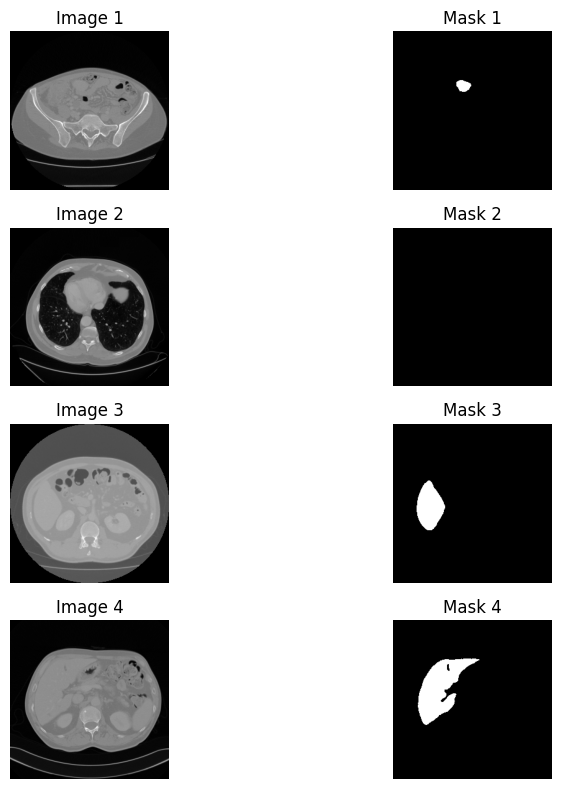

In [22]:
import random
import matplotlib.pyplot as plt

# Choose 4 random samples (batch index, sample index within batch)
samples = []
image = []
label = []
for _ in range(4):
    batch_idx = random.randint(0, len(train_loader) - 1)
    batch = list(train_loader)[batch_idx]
    sample_idx = random.randint(0, batch['image'].shape[0] - 1)

    img = batch['image'][sample_idx].squeeze()     # [H, W]
    mask = batch['semantic'][sample_idx].squeeze() # [H, W]
    samples.append((img, mask))
    image = np.unique(img)
    label = np.unique(mask)

# print(image)
# print(label)

# Plot
plt.figure(figsize=(10, 8))
for i, (img, mask) in enumerate(samples):
    plt.subplot(4, 2, 2*i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Image {i+1}")
    plt.axis('off')

    plt.subplot(4, 2, 2*i + 2)
    plt.imshow(mask, cmap='gray')
    plt.title(f"Mask {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [23]:
print(len(train_loader), len(valid_loader))

251 103


In [24]:
# Create model or load a checkpoint

labels_dir = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/EfficientPS"



# Add the directory to sys.path
if labels_dir not in sys.path:
    sys.path.append(labels_dir)

from efficientps.panoptic_segmentation_module import *
from efficientps import EffificientPS
from efficientps.panoptic_metrics import generate_pred_panoptic


# if os.path.exists(cfg.CHECKPOINT_PATH):
#     print('""""""""""""""""""""""""""""""""""""""""""""""')
#     print("Loading model from {}".format(cfg.CHECKPOINT_PATH))
#     print('""""""""""""""""""""""""""""""""""""""""""""""')
#     efficientps = EffificientPS.load_from_checkpoint(cfg=cfg,
#         checkpoint_path=cfg.CHECKPOINT_PATH)
# else:
#     print('""""""""""""""""""""""""""""""""""""""""""""""')
#     print("Creating a new model")
#     print('""""""""""""""""""""""""""""""""""""""""""""""')
#     efficientps = EffificientPS(cfg)
#     cfg.CHECKPOINT_PATH = None


import os
import random
import numpy as np
import torch

SEED = 42

# Set environment-level seeds
# os.environ["PYTHONHASHSEED"] = str(SEED)

# Python, NumPy, and PyTorch seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # For multi-GPU setups

# Force deterministic operations
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if cfg.CHECKPOINT_PATH and os.path.exists(cfg.CHECKPOINT_PATH):
    print(f'Loading model from {cfg.CHECKPOINT_PATH}')
    efficientps = EffificientPS.load_from_checkpoint(cfg=cfg, checkpoint_path=cfg.CHECKPOINT_PATH)
else:
    print("Creating a new model")
    efficientps = EffificientPS(cfg)
    # checkpoint_path_ = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/checkpoints_twowayFPN_atlasIRCAD/efficientps_epoch11.pth"
    # state_dict = torch.load(checkpoint_path_, map_location='cuda' if torch.cuda.is_available() else 'cpu')
    # efficientps.load_state_dict(state_dict)


logger.info(efficientps.print)
# # Callbacks / Hooks
early_stopping = EarlyStopping('PQ', patience=5, mode='max')
checkpoint = ModelCheckpoint(monitor='PQ',
                                mode='max',
                                dirpath=cfg.CALLBACKS.CHECKPOINT_DIR,
                                save_last=True,
                                verbose=True,)

# Create a pytorch lighting trainer
# trainer = pl.Trainer(
#     # weights_summary='full',
#     gpus=1,
#     num_sanity_val_steps=0,
#     # fast_dev_run=True,
#     callbacks=[early_stopping, checkpoint],
#     precision=cfg.PRECISION,
#     resume_from_checkpoint=cfg.CHECKPOINT_PATH,
#     gradient_clip_val=15,
#     accumulate_grad_batches=cfg.SOLVER.ACCUMULATE_GRAD
# )


logger.addHandler(logging.StreamHandler())


Creating a new model


/home/miglab/miniconda3/lib/python3.12/site-packages/pytorch_lightning/core/lightning.py:2054: DeprecationWarning: `torch.distributed._sharded_tensor` will be deprecated, use `torch.distributed._shard.sharded_tensor` instead
  from torch.distributed._sharded_tensor import pre_load_state_dict_hook, state_dict_hook
<bound method LightningModule.print of EffificientPS(
  (backbone): EfficientNet(
    (_conv_stem): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (_bn0): InPlaceABN(64, eps=0.001, momentum=0.1, affine=True, activation=leaky_relu[0.01])
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_depthwise_conv): Conv2dStaticSamePadding(
          64, 64, kernel_size=(3, 3), stride=[1, 1], groups=64, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): InPlaceABN(64, eps=0.001, momentum=0.1, affine=True, activation=leaky_relu[0.01])
        (_se_reduce): Identity()
        (_se_expand): Identity()
        (_

In [25]:
# for param in efficientps.backbone.parameters():
#     param.requires_grad = False

for name, param in efficientps.named_parameters():
    # print(f"{name}: requires_grad = {param.requires_grad}")
    if param.requires_grad == False:
        raise Exception


In [26]:
# import os
# import random
# import numpy as np
# import torch

# SEED = 42

# # Set environment-level seeds
# os.environ["PYTHONHASHSEED"] = str(SEED)

# # Python, NumPy, and PyTorch seeds
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)
# torch.cuda.manual_seed(SEED)
# torch.cuda.manual_seed_all(SEED)  # For multi-GPU setups

# # Force deterministic operations
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

# # from efficientps import EffificientPS

# efficientps = EffificientPS(cfg)  # Must come after all seeds are set

# import torch

# B, C, H, W = 2, 1, 256, 256
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Load model
# # efficientps = EffificientPS(cfg)
# # checkpoint_path_ = "//mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/checkpoints_only_sem_head_fa_atlas(patientwiseDiceCEwithoutAttn))/efficientps_epoch18.pth"
# # state_dict = torch.load(checkpoint_path_, map_location=device)
# # efficientps.load_state_dict(state_dict)
# efficientps.to(device)
# # efficientps.eval()

# # Seed and synthetic input
# torch.manual_seed(42)
# synthetic_batch = {
#     "image": torch.rand(B, C, H, W, device=device),
#     "semantic": torch.randint(0, 2, (B, H, W), device=device)
# }



# # Check determinism
# # with torch.no_grad():
# pred1, _ = efficientps.shared_step(synthetic_batch)
# pred2, _ = efficientps.shared_step(synthetic_batch)

# print(synthetic_batch['image'])
# print(pred1['semantic'][0, 0, 150, :])

# is_equal = torch.equal(pred1['semantic'], pred2['semantic'])
# print("Are outputs deterministic?", is_equal)
# raise Exception


In [27]:
# print(f"{'Parameter Name':60} {'Shape':>25} {'Requires Grad':>15}")
# print("-" * 100)

# for name, param in efficientps.named_parameters():
#     print(f"{name:60} {str(tuple(param.shape)):>25} {str(param.requires_grad):>15}")


In [28]:
# import torch
# from torch.profiler import profile, ProfilerActivity

# model = efficientps.to("cuda").eval()
# inputs = {"image": torch.randn(1, 1, 256, 256).to("cuda")}

# with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], record_shapes=True) as prof:
#     with torch.no_grad():
#         model(inputs)

# print(prof.key_averages().table(sort_by="cuda_time_total"))


In [29]:
# total_params = sum(p.numel() for p in efficientps.backbone.parameters() if p.requires_grad)
# print(f"Total Trainable Parameters: {total_params:,}")

# Total parameters (trainable + non-trainable)
total_params = sum(p.numel() for p in efficientps.parameters())

# Trainable parameters only
trainable_params = sum(p.numel() for p in efficientps.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
# Total Parameters: 57,353,838
# Trainable Parameters: 57,353,838

# B4
# Total Parameters: 18,727,974
# Trainable Parameters: 18,727,974



Total Parameters: 57,353,802
Trainable Parameters: 57,353,802


In [30]:
# import torch
# import time

# # Ensure your model is on GPU and in eval mode
# model = efficientps.to("cuda").eval()

# # Create a synthetic input (modify shape if needed)
# sample = {"image": torch.randn(1, 1, 256, 256).to("cuda")}

# # Warm-up (important for accurate timing on GPU)
# for _ in range(10):
#     with torch.no_grad():
#         _ = model(sample)

# # Synchronize CUDA before and after to ensure accurate timing
# torch.cuda.synchronize()
# start_time = time.time()

# with torch.no_grad():
#     _ = model(sample)

# torch.cuda.synchronize()
# end_time = time.time()

# inference_time_ms = (end_time - start_time) * 1000
# print(f"Inference time per sample: {inference_time_ms:.3f} ms")
# raise Exception
# # # 33.908 ms for without atten
# # # 35.812 ms for cbam
# # # 34.153 ms for ECA
# # # 28.480 ms for FA

In [31]:
# import torch
# from fvcore.nn import FlopCountAnalysis, flop_count_table, parameter_count_table

# # Replace FlashAttention2D with dummy passthrough module
# class DummyFlashAttention(torch.nn.Module):
#     def __init__(self):
#         super().__init__()
#     def forward(self, x):
#         return x

# # Replace the flash attention layers in your model temporarily
# efficientps.fpn.flash_attn_x4 = DummyFlashAttention()
# efficientps.fpn.flash_attn_x8 = DummyFlashAttention()
# efficientps.fpn.flash_attn_x16 = DummyFlashAttention()
# efficientps.fpn.flash_attn_x32 = DummyFlashAttention()

# # Move model to CPU
# efficientps.eval().cpu()

# # Prepare dummy input
# batch = {"image": torch.randn(1, 1, 256, 256)}  # shape: [B, C, H, W]

# # Analyze FLOPs
# flops = FlopCountAnalysis(efficientps, batch)

# # Print results
# print("Total FLOPs:", flops.total())
# print("\nFLOP Table:\n", flop_count_table(flops))
# print("\nParameter count:\n", parameter_count_table(efficientps))


# # 7830056960 + 268435456

In [32]:
# from fvcore.nn import FlopCountAnalysis, flop_count_table, parameter_count_table
# import torch

# # Prepare input
# batch = {"image": torch.randn(1, 1, 256, 256)}  # Batch size 1 for FLOP analysis

# # Put model on CPU for analysis (can also be on CUDA)
# efficientps.eval()
# efficientps.cpu()

# # Compute FLOPs
# flops = FlopCountAnalysis(efficientps, batch)

# # Print raw total FLOPs
# print("Total FLOPs:", flops.total())

# # ✅ This works for older fvcore
# print("\nFLOP Table:\n", flop_count_table(flops))

# # Parameter count
# print("\nParameter count:\n", parameter_count_table(efficientps))

# # # 7830319104 flops for no atten
# # # 7830928640 flops for cbam
# # # 7834506240 flops for eca
# # # 8098492416 flops for fa
# raise Exception

In [33]:
# import torch, torch.nn.functional as F
# import matplotlib.pyplot as plt
# import numpy as np

# def dice_score_from_logits(pred_logits, target, num_classes=3, smooth=1e-6):
#     # Convert logits to class predictions
#     pred = torch.argmax(pred_logits, dim=1)

#     # One-hot encode both pred and target
#     pred = F.one_hot(pred, num_classes).permute(0, 3, 1, 2).float()
#     target = F.one_hot(target, num_classes).permute(0, 3, 1, 2).float()

#     # Dice per class, per batch
#     intersection = (pred * target).sum(dim=(2, 3))
#     union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
#     dice = (2. * intersection + smooth) / (union + smooth)  # shape: (B, C)

#     return dice.mean(dim=0)  # average over batch, return class-wise scores

# def compute_dice_loss_batch(pred_logits, batch, num_classes=3):
#     gt = batch['semantic'].to(pred_logits.device)
#     class_dice = dice_score_from_logits(pred_logits, gt, num_classes=num_classes)
#     return class_dice  # returns a tensor of shape (num_classes,)

# # === Colormap helper (unchanged)
# def apply_custom_colormap(mask):
#     colormap = {
#         0: [0, 0, 0],
#         1: [255, 255, 255],
#         2: [0, 0, 255]
#     }
#     h, w = mask.shape
#     color_mask = np.zeros((h, w, 3), dtype=np.uint8)
#     for label, color in colormap.items():
#         color_mask[mask == label] = color
#     return color_mask

# # === Model loading (unchanged)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ckpt_dir = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/checkpoints_liver_tumor_atlas_WA"

# efficientps = EffificientPS(cfg)
# efficientps.load_state_dict(torch.load(f"{ckpt_dir}/efficientps_epoch99.pth", map_location=device))
# efficientps.to(device)
# efficientps.eval()

# # === Accumulator for Dice
# dice_class_scores = []

# with torch.no_grad():
#     for batch in valid_loader:
#         batch['image'] = batch['image'].to(device)
#         batch['semantic'] = batch['semantic'].to(device)

#         preds, _ = efficientps.shared_step(batch)

#         # Compute Dice for this batch (returns tensor of 3 values for 3 classes)
#         batch_dice = compute_dice_loss_batch(preds['semantic'], batch, num_classes=3)
#         dice_class_scores.append(batch_dice)

# # === Final average per class and overall Dice
# dice_class_scores = torch.stack(dice_class_scores)  # shape: (N_batches, num_classes)
# mean_dice_per_class = dice_class_scores.mean(dim=0) 

# print("\n✅ Average Dice Scores:")
# for class_id, score in enumerate(mean_dice_per_class.tolist()):
#     print(f"Class {class_id} → Dice: {score:.4f}")

# print(f"\n🎯 Overall Mean Dice: {mean_dice_per_class.mean().item():.4f}")


In [34]:
# import torch
# import torch.nn.functional as F
# import matplotlib.pyplot as plt
# import numpy as np

# # === Global Dice Score (not per class) 
# def global_dice_score(pred_logits, target, num_classes=3, smooth=1e-6):
#     pred_classes = torch.argmax(pred_logits, dim=1)  # (B, H, W)

#     pred_onehot = F.one_hot(pred_classes, num_classes=num_classes).permute(0, 3, 1, 2).float()
#     target_onehot = F.one_hot(target, num_classes=num_classes).permute(0, 3, 1, 2).float()

#     pred_flat = pred_onehot.reshape(-1)     # FIXED HERE
#     target_flat = target_onehot.reshape(-1) # FIXED HERE

#     intersection = (pred_flat * target_flat).sum()
#     union = pred_flat.sum() + target_flat.sum()

#     dice = (2. * intersection + smooth) / (union + smooth)
#     return dice.item()

# # === Colormap helper (unchanged)
# def apply_custom_colormap(mask):
#     colormap = {
#         0: [0, 0, 0],
#         1: [255, 255, 255],
#         2: [0, 0, 255]
#     }
#     h, w = mask.shape
#     color_mask = np.zeros((h, w, 3), dtype=np.uint8)
#     for label, color in colormap.items():
#         color_mask[mask == label] = color
#     return color_mask

# # === Model loading
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ckpt_dir = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/checkpoints_liver_tumor_atlas_WA"

# efficientps = EffificientPS(cfg)
# efficientps.load_state_dict(torch.load(f"{ckpt_dir}/efficientps_epoch99.pth", map_location=device))
# efficientps.to(device)
# efficientps.eval()

# # === Evaluate
# dice_scores = []

# with torch.no_grad():
#     for batch in valid_loader:
#         batch['image'] = batch['image'].to(device)
#         batch['semantic'] = batch['semantic'].to(device)

#         preds, _ = efficientps.shared_step(batch)

#         # Global Dice for the batch
#         dice = global_dice_score(preds['semantic'], batch['semantic'], num_classes=3)
#         dice_scores.append(dice)

# # === Final Score
# avg_dice = sum(dice_scores) / len(dice_scores)
# print(f"\n✅ Global Pixel-wise Dice Score (Validation Set): {avg_dice:.4f}")


In [35]:
# import torch
# import torch.nn.functional as F

# def dice_loss_per_class(y_true, y_pred, smooth=1e-6):
#     """
#     Computes Dice loss per class for one sample.
#     y_true and y_pred are both (H, W) tensors with integer labels.
#     """
#     num_classes = y_pred.shape[0]  # (C, H, W)
#     losses = []

#     for c in range(num_classes):
#         y_true_c = (y_true == c).float()
#         y_pred_c = y_pred[c]  # Already a float mask (logits or probs)

#         intersection = (y_true_c * y_pred_c).sum()
#         union = y_true_c.sum() + y_pred_c.sum()

#         dice = (2. * intersection + smooth) / (union + smooth)
#         losses.append(1 - dice)

#     return sum(losses) / len(losses)


# def compute_dice_loss_batch(pred_logits, batch, num_classes=3):
#     """
#     pred_logits: Tensor of shape (B, C, H, W)
#     batch['semantic']: Tensor of shape (B, H, W) with integer class labels
#     """
#     gt = batch['semantic']  # (B, H, W)
#     probs = F.softmax(pred_logits, dim=1)  # (B, C, H, W)

#     batch_size = gt.shape[0]
#     total_loss = 0.0

#     for i in range(batch_size):
#         pred_sample = probs[i]           # (C, H, W)
#         target_sample = gt[i]            # (H, W)
#         loss = dice_loss_per_class(target_sample, pred_sample)
#         total_loss += loss

#     return total_loss / batch_size if batch_size > 0 else 0.0
# with torch.no_grad():
#     total_dice_loss = 0.0
#     for batch in valid_loader:
#         batch['image'] = batch['image'].to(device)
#         batch['semantic'] = batch['semantic'].to(device)

#         preds, _ = efficientps.shared_step(batch)
#         dice_loss_value = compute_dice_loss_batch(preds['semantic'], batch, num_classes=3)
#         total_dice_loss += dice_loss_value

# avg_dice_loss = total_dice_loss / len(valid_loader)
# print(f"\n🎯 Avg. Multi-Class Dice Loss (Validation): {avg_dice_loss:.4f}")

In [36]:
# import torch
# import torch.nn.functional as F

# def dice_score_per_class(pred_one_hot, target_one_hot, smooth=1e-6):
#     """
#     Computes Dice score per class across batch.
    
#     Args:
#         pred_one_hot: Tensor of shape (N, C, H, W)
#         target_one_hot: Tensor of shape (N, C, H, W)
    
#     Returns:
#         Tensor of shape (C,) containing Dice scores for each class
#     """
#     intersection = torch.sum(pred_one_hot * target_one_hot, dim=(0, 2, 3))  # per class
#     union = torch.sum(pred_one_hot + target_one_hot, dim=(0, 2, 3))         # per class
#     dice = (2. * intersection + smooth) / (union + smooth)
#     return dice  # shape: (C,)
    

# def compute_dice_loss_batch(pred, batch, num_classes=3, ignore_index=0):
#     """
#     Compute per-class Dice score for each batch.
#     Averages over classes excluding `ignore_index` (default: background).

#     Args:
#         pred: Dictionary with key 'semantic' of shape (B, C, H, W)
#         batch: Dict with key 'semantic' as GT of shape (B, H, W)
#         num_classes: Total number of segmentation classes.
#         ignore_index: Label index to ignore during average (default: 0 for background)
    
#     Returns:
#         avg_dice_loss: scalar float (mean of selected class dice losses)
#         per_class_dice: Tensor of shape (C,) with class-wise Dice scores
#     """
#     pred_logits = pred['semantic']                  # (B, C, H, W)
#     gt = batch['semantic'].to(pred_logits.device)   # (B, H, W)
    
#     # Get class predictions
#     pred_classes = torch.argmax(pred_logits, dim=1)  # (B, H, W)

#     # One-hot encode
#     pred_one_hot = F.one_hot(pred_classes, num_classes=num_classes).permute(0, 3, 1, 2).float()
#     gt_one_hot   = F.one_hot(gt,           num_classes=num_classes).permute(0, 3, 1, 2).float()

#     # Per-class Dice
#     per_class_dice = dice_score_per_class(pred_one_hot, gt_one_hot)  # (C,)

#     # Exclude background (label 0) when averaging
#     class_indices = [i for i in range(num_classes) if i != ignore_index]
#     avg_dice_loss = 1.0 - per_class_dice[class_indices].mean()

#     return avg_dice_loss.item(), per_class_dice  # Scalar + Tensor (C,)

# total_loss = 0.0
# total_batches = 0
# per_class_dice_total = torch.zeros(3, device=device)  # num_classes=3

# with torch.no_grad():
#     for batch in valid_loader:
#         batch['image'] = batch['image'].to(device)
#         batch['semantic'] = batch['semantic'].to(device)

#         preds, _ = efficientps.shared_step(batch)

#         dice_loss_val, per_class_dice = compute_dice_loss_batch(preds, batch, num_classes=3, ignore_index=0)

#         total_loss += dice_loss_val
#         per_class_dice_total += per_class_dice
#         total_batches += 1

# avg_loss = total_loss / total_batches
# avg_per_class_dice = per_class_dice_total / total_batches

# print(f"\n✅ Avg Multi-class Dice Loss (Validation): {avg_loss:.4f}")
# print(f"📊 Per-class Dice Scores:")
# print(f"  Background (0): {avg_per_class_dice[0]:.4f}")
# print(f"  Liver      (1): {avg_per_class_dice[1]:.4f}")
# print(f"  Tumor      (2): {avg_per_class_dice[2]:.4f}")


In [37]:
# import torch, torch.nn.functional as F
# import matplotlib.pyplot as plt
# import numpy as np

# def dice_loss(pred, target, num_classes=3, smooth=1e-6):
#     if pred.dim() == 3:
#         pred = F.one_hot(pred.long(), num_classes).permute(0, 3, 1, 2).float()
#     else:
#         pred = F.softmax(pred, dim=1)
#     target = F.one_hot(target.long(), num_classes).permute(0, 3, 1, 2).float()
#     intersection = (pred * target).sum(dim=(2, 3))
#     union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
#     dice = (2. * intersection + smooth) / (union + smooth)
#     return 1 - dice.mean()

# def compute_dice_loss_batch(pred, batch, num_classes=3):
#     gt = batch['semantic'].to(pred.device)
#     return dice_loss(pred, gt, num_classes=num_classes).item()

# # Define colormap for visualization: 0 → black, 1 → white, 2 → blue
# def apply_custom_colormap(mask):
#     colormap = {
#         0: [0, 0, 0],        # Black
#         1: [255, 255, 255],  # White
#         2: [0, 0, 255]       # Blue
#     }
#     h, w = mask.shape
#     color_mask = np.zeros((h, w, 3), dtype=np.uint8)
#     for label, color in colormap.items():
#         color_mask[mask == label] = color
#     return color_mask

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ckpt_dir = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/checkpoints_liver_tumor_atlas_WA"

# efficientps = EffificientPS(cfg)
# efficientps.load_state_dict(torch.load(f"{ckpt_dir}/efficientps_epoch99.pth", map_location=device))
# efficientps.to(device)
# efficientps.eval()

# K = 10
# samples = []
# count = 0

# with torch.no_grad():
#     for batch in valid_loader:
#         count += 1
#         if count == 10:
#             raise Exception
#         batch['image'] = batch['image'].to(device)
#         batch['semantic'] = batch['semantic'].to(device)
        
#         preds, _ = efficientps.shared_step(batch)

#         semantic_logits = torch.argmax(preds['semantic'], dim=1)
#         panoptic = panoptic_segmentation(cfg, preds, device)   # (B,H,W)
#         gt  = batch['semantic']
#         print(panoptic.shape)
#         print(gt.unique(), gt.shape)
#         print(panoptic.unique())

#         # Convert to NumPy
#         if isinstance(panoptic, torch.Tensor):
#             panoptic = panoptic.cpu().numpy()
#         if isinstance(gt, torch.Tensor):
#             gt = gt.cpu().numpy()

#         batch_size = panoptic.shape[0]

#         # Plot
#         plt.figure(figsize=(12, batch_size * 2))
#         for i in range(batch_size):
#             # Ground Truth
#             plt.subplot(batch_size, 2, 2 * i + 1)
#             plt.imshow(apply_custom_colormap(gt[i]))
#             plt.title(f"GT {i}")
#             plt.axis("off")
            
#             # Prediction
#             plt.subplot(batch_size, 2, 2 * i + 2)
#             plt.imshow(apply_custom_colormap(panoptic[i]))
#             plt.title(f"Pred {i}")
#             plt.axis("off")

#         plt.tight_layout()
#         plt.show()


#         # raise Exception
        
#         # for i in range(panoptic.size(0)):
#         #     if len(samples) == K:
#         #         break 
#         #     gt  = batch['semantic'][i].cpu().numpy()
#         #     # print(np.unique(gt))
#         #     pr  = panoptic[i].cpu().numpy()
#         #     # print(np.unique(pr))
#         #     err = (gt != pr).astype(float)
#         #     samples.append((gt, pr, err))
#         # if len(samples) == K:
#         #     break
# # import random
# # samples = random.sample(samples, K)

# # fig, axes = plt.subplots(K, 3, figsize=(9, 3*K))
# # for r, (gt, pr, err) in enumerate(samples):
# #     axes[r, 0].imshow(gt);  axes[r, 0].set_title("GT");      axes[r, 0].axis("off")
# #     axes[r, 1].imshow(pr);  axes[r, 1].set_title("Pred");    axes[r, 1].axis("off")
# #     axes[r, 2].imshow(err); axes[r, 2].set_title("Error");   axes[r, 2].axis("off")
# # plt.tight_layout(); plt.show()


In [38]:
import warnings
warnings.simplefilter("ignore", UserWarning)

# import torch
# import os
# import numpy as np


seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)  # optional
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# torch.use_deterministic_algorithms(True)
# os.environ['PYTHONHASHSEED'] = str(seed)
# os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

from panopticapi.evaluation import pq_compute
from torch.amp import autocast

from torch.amp import GradScaler
scaler = GradScaler()

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = y_true.view(-1).float()
    y_pred_f = y_pred.view(-1).float()
    intersection = (y_true_f * y_pred_f).sum()
    return 1 - ((2. * intersection + smooth) / (y_true_f.sum() + y_pred_f.sum() + smooth))

def compute_dice_loss_batch(panoptic_result, batch):
    gt = batch['semantic']  # CUDA tensor
    
    pred = panoptic_result  # CUDA tensor
    # pred = torch.where(pred == 1, torch.tensor(0, device=pred.device), torch.tensor(1, device=pred.device))
    
    batch_size = gt.shape[0]
    dice_losses = []
    for i in range(batch_size):
        loss = dice_loss(gt[i], pred[i])
        dice_losses.append(loss.item())

    del gt, pred
    return sum(dice_losses) / len(dice_losses) if dice_losses else 0.0

# def dice_loss(pred, target, num_classes=3, smooth=1e-6):
#     """
#     pred   : (B, H, W) class predictions OR (B, C, H, W) logits
#     target : (B, H, W) class labels
#     """
#     if pred.dim() == 3:  # class indices → one-hot
#         pred = F.one_hot(pred.long(), num_classes).permute(0, 3, 1, 2).float()
#     else:  # logits → softmax probs
#         pred = F.softmax(pred, dim=1)

#     target = F.one_hot(target.long(), num_classes).permute(0, 3, 1, 2).float()

#     intersection = (pred * target).sum(dim=(2, 3))
#     union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
#     dice = (2. * intersection + smooth) / (union + smooth)
#     return 1 - dice.mean()


# # ---------------------------- 
# # Compute batch Dice loss
# # ----------------------------
# def compute_dice_loss_batch(pred, batch, num_classes=3):
#     gt = batch['semantic'].to(pred.device)
#     loss = dice_loss(pred, gt, num_classes=num_classes)
#     return loss.item()

# Load or init model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
efficientps.to(device)
checkpoint_path = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/checkpoints_twowayFPN_WA_IRCAD"
os.makedirs(checkpoint_path, exist_ok=True)

optimizer_config = efficientps.configure_optimizers()
optimizer = optimizer_config['optimizer']
scheduler = optimizer_config['lr_scheduler']
# print(optimizer)
# raise Exception
num_epochs = cfg.SOLVER.MAX_EPOCHS
# num_epochs = 50
log_interval = 200

best_val_loss = 50.0
patience = 8
epochs_without_improvement = 0

for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    
    efficientps.train()
    total_train_loss = 0.0
    total_train_dice_loss = 0.0
    

    for batch_idx, batch in enumerate(train_loader):
        # if batch_idx == 30:
        #     break
        batch['image'] = batch['image'].to(device)
        batch['semantic'] = batch['semantic'].to(device)
        # for inst in batch['instance']:
        #     inst.gt_masks = inst.gt_masks.to(device)
        #     inst.gt_classes = inst.gt_classes.to(device)
        #     inst.gt_boxes = inst.gt_boxes.to(device)

        optimizer.zero_grad(set_to_none=True)
        # print(batch['image'].shape)
        # raise Exception
        # with autocast(device_type='cuda', dtype=torch.float16):
        predictions, loss = efficientps.shared_step(batch)   
        # print(predictions['semantic'].shape)
        # print(predictions['semantic'].unique())
        # print(loss)
        # raise Exception
        # print(batch['image'][0, 0, 150, :])
        # print(predictions['semantic'][0, 0, 150, :])
        # raise Exception

        panoptic_result = panoptic_segmentation(cfg, predictions, device)
        # print(batch['semantic'].unique(), panoptic_result.unique())
        # raise Exception

        # print(predictions['semantic'].min(), predictions['semantic'].max())
        # print(panoptic_result.min(), panoptic_result.max())
        # print(panoptic_result.shape, batch['semantic'].shape)
        # print(predictions['semantic'].shape)
        # raise Exception
        dice_loss_batch = compute_dice_loss_batch(panoptic_result, batch)
        # print(loss)
        # raise Exception

        total_loss = sum(loss.values()) #No FA
        total_loss.backward()    # NO FA
        optimizer.step()   # NO FA

        # """ FA BACKWARD CODE """
        # total_loss = sum(loss.values())
        # scaler.scale(total_loss).backward()
        # scaler.step(optimizer)
        # scaler.update()

        # """ Till THIS LINE """


        total_train_loss += total_loss.item()
        total_train_dice_loss += dice_loss_batch

        if batch_idx % log_interval == 0:
            print(f"Step {batch_idx}/{len(train_loader)}, Loss: {total_loss:.4f}")
            
        # Cleanup
        del predictions, loss, total_loss, panoptic_result
        torch.cuda.empty_cache()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_train_dice_loss = total_train_dice_loss / len(train_loader)
    print(f"Average Training Loss: {avg_train_loss:.4f}")
    print(f"Average Training Dice Score : {1 - avg_train_dice_loss:.4f}")
    
    scheduler.step(avg_train_loss)

    ### VALIDATION
    efficientps.eval()
    total_val_loss = 0.0
    total_dice_loss = 0.0
    val_outputs = []

    with torch.no_grad():
        efficientps.eval()
        for batch in valid_loader:
            batch['image'] = batch['image'].to(device)
            batch['semantic'] = batch['semantic'].to(device)
            # for inst in batch['instance']:
            #     inst.gt_masks = inst.gt_masks.to(device)
            #     inst.gt_classes = inst.gt_classes.to(device)
            #     inst.gt_boxes = inst.gt_boxes.to(device)
            # def check_model_weights_for_nan(model):
            #     has_nan = False
            #     for name, param in model.named_parameters():
            #         if param.requires_grad:
            #             print(param.min(), param.max())
            #             if torch.isnan(param).any():
            #                 print(f"NaN found in: {name}")
            #                 has_nan = True
            #             elif torch.isinf(param).any():
            #                 print(f"Inf found in: {name}")
            #                 has_nan = True
            #     if not has_nan:
            #         print("✅ No NaNs or Infs found in model weights.")
            # check_model_weights_for_nan(efficientps)
            # with autocast(device_type='cuda', dtype=torch.float16):
            predictions, loss = efficientps.shared_step(batch)
            
            panoptic_result = panoptic_segmentation(cfg, predictions, device)
            dice_loss_batch = compute_dice_loss_batch(panoptic_result, batch)

            total_val_loss += sum(loss.values()).item()
            total_dice_loss += dice_loss_batch

            # val_outputs.append({
            #     'val_loss': sum(loss.values()).item(),
            #     'panoptic': panoptic_result,
            #     'image_id': batch['image_id']
            # })

            # Free memory immediately
            del predictions, loss, panoptic_result
            torch.cuda.empty_cache()

    avg_val_loss = total_val_loss / len(valid_loader)
    avg_dice_val_loss = total_dice_loss / len(valid_loader)
    avg_dice_val_score = 1 - avg_dice_val_loss

    print(f"Validation Loss: {avg_val_loss:.4f}")
    print(f"Average Dice Validation Score: {avg_dice_val_score:.4f}")

    # Save prediction results for PQ (move to CPU)
    # generate_pred_panoptic(cfg, val_outputs)  # Ensure this doesn't accumulate GPU memory

    # pq_res = pq_compute(
    #     gt_json_file=os.path.join(cfg.DATASET_PATH, cfg.VALID_JSON),
    #     pred_json_file=os.path.join(cfg.DATASET_PATH, cfg.PRED_JSON),
    #     gt_folder=os.path.join(cfg.DATASET_PATH, "output/cityscapes_panoptic_val/"),
    #     pred_folder=os.path.join(cfg.DATASET_PATH, cfg.PRED_DIR)
    # )
    # del val_outputs
    current_val_loss = avg_val_loss
    # current_pq = 100 * pq_res['All']['pq']
    # print(f"PQ: {current_pq:.2f}, SQ: {100 * pq_res['All']['sq']:.2f}, RQ: {100 * pq_res['All']['rq']:.2f}")
    
    # Log metrics
    metrics_csv_path = os.path.join(cfg.DATASET_PATH, "scores_liver.csv")
    with open(metrics_csv_path, "a") as f:
        f.write(f"Epoch :{epoch+1}, Avg. Train loss: {avg_train_loss:.4f}, Avg. Val loss: {avg_val_loss:.4f}, Avg. Train Dice: {1-avg_train_dice_loss:.4f}, Avg. Val Dice: {avg_dice_val_score:.4f}\n")


    torch.save(efficientps.state_dict(), f"{checkpoint_path}/efficientps_epoch{epoch+1}.pth")

    # Early stopping
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        epochs_without_improvement = 0
        print("✅ Best model saved!")
    else:
        epochs_without_improvement += 1
        print(f"🚨 No improvement for {epochs_without_improvement} epochs.")

    if epochs_without_improvement >= patience:
        print(f"⏹️ Early stopping triggered after {epoch+1} epochs! Best Val loss: {best_val_loss:.2f}")
        # break
    torch.cuda.empty_cache()
# torch.Size([8, 48, 128, 128])
# torch.Size([8, 80, 64, 64])
# torch.Size([8, 224, 32, 32])
# torch.Size([8, 2560, 16, 16])

AdamW

Epoch [1/100]
Step 0/251, Loss: 12.3246
Step 200/251, Loss: 3.9896
Average Training Loss: 3.8324
Average Training Dice Score : 0.5520
Validation Loss: 4.9763
Average Dice Validation Score: 0.5086
✅ Best model saved!

Epoch [2/100]
Step 0/251, Loss: 2.2437
Step 200/251, Loss: 2.2664
Average Training Loss: 2.6301
Average Training Dice Score : 0.6734
Validation Loss: 5.2436
Average Dice Validation Score: 0.4844
🚨 No improvement for 1 epochs.

Epoch [3/100]
Step 0/251, Loss: 3.0091
Step 200/251, Loss: 3.3440
Average Training Loss: 2.2715
Average Training Dice Score : 0.7121
Validation Loss: 4.2769
Average Dice Validation Score: 0.5167
✅ Best model saved!

Epoch [4/100]
Step 0/251, Loss: 2.2817
Step 200/251, Loss: 1.2696
Average Training Loss: 2.0776
Average Training Dice Score : 0.7755
Validation Loss: 4.4679
Average Dice Validation Score: 0.5802
🚨 No improvement for 1 epochs.

Epoch [5/100]
Step 0/251, Loss: 2.3079
Step 200/251, Loss: 3.3930
Average Training Loss: 1.9328
Average Tr

In [39]:
# batch1 = next(iter(train_loader))
# batch2 = next(iter(train_loader))
# print(batch1['image'].shape)
# # This should print True
# print(torch.equal(batch1['image'], batch2['image']))

def check_model_weights_for_nan(model):
    has_nan = False
    for name, param in model.named_parameters():
        if param.requires_grad:
            print(param.min(), param.max())
            if torch.isnan(param).any():
                print(f"NaN found in: {name}")
                has_nan = True
            elif torch.isinf(param).any():
                print(f"Inf found in: {name}")
                has_nan = True
    if not has_nan:
        print("✅ No NaNs or Infs found in model weights.")
check_model_weights_for_nan(efficientps)



tensor(-0.1612, device='cuda:0', grad_fn=<MinBackward1>) tensor(0.1794, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(0.9764, device='cuda:0', grad_fn=<MinBackward1>) tensor(1.0258, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(-0.0238, device='cuda:0', grad_fn=<MinBackward1>) tensor(0.0267, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(-0.3448, device='cuda:0', grad_fn=<MinBackward1>) tensor(0.3493, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(0.9762, device='cuda:0', grad_fn=<MinBackward1>) tensor(1.0220, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(-0.0238, device='cuda:0', grad_fn=<MinBackward1>) tensor(0.0195, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(-0.1576, device='cuda:0', grad_fn=<MinBackward1>) tensor(0.1526, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(0.9844, device='cuda:0', grad_fn=<MinBackward1>) tensor(1.0379, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(-0.0320, device='cuda:0', grad_fn=<MinBackward1>) tensor(0.0326, device='cuda:0', grad_fn=<M

In [40]:
raise Exception

Exception: 

In [ ]:
# import torch, torch.nn.functional as F

# def dice_loss(pred, target, num_classes=3, smooth=1e-6):
#     if pred.dim() == 3:
#         pred = F.one_hot(pred.long(), num_classes).permute(0, 3, 1, 2).float()
#     else:
#         pred = F.softmax(pred, dim=1)
#     target = F.one_hot(target.long(), num_classes).permute(0, 3, 1, 2).float()
#     intersection = (pred * target).sum(dim=(2, 3))
#     union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
#     dice = (2. * intersection + smooth) / (union + smooth)
#     return 1 - dice.mean()

# def compute_dice_loss_batch(pred, batch, num_classes=3):
#     gt = batch['semantic'].to(pred.device)
#     return dice_loss(pred, gt, num_classes=num_classes).item()

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ckpt_dir = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/checkpoints_only_sem_head_fa_atlas"

# for epoch in range(1, 81):
#     efficientps = EffificientPS(cfg)
#     ckpt_path = f"{ckpt_dir}/efficientps_epoch{epoch}.pth"
#     efficientps.load_state_dict(torch.load(ckpt_path, map_location=device))
#     efficientps.to(device)
#     efficientps.eval()
#     total_val_loss = 0.0
#     total_dice_loss = 0.0
#     with torch.no_grad():
#         for batch in valid_loader:
#             batch['image'] = batch['image'].to(device)
#             batch['semantic'] = batch['semantic'].to(device)
#             predictions, loss = efficientps.shared_step(batch)
#             panoptic_result = panoptic_segmentation(cfg, predictions, device)
#             # print(panoptic_result.unique(), batch['semantic'].unique())
#             # raise exception
#             total_dice_loss += compute_dice_loss_batch(panoptic_result, batch, num_classes=3)
#             total_val_loss += sum(loss.values()).item()
#             del predictions, loss, panoptic_result
#             torch.cuda.empty_cache()
#     avg_val_loss = total_val_loss / len(valid_loader)
#     avg_dice_val_loss = total_dice_loss / len(valid_loader)
#     avg_dice_val_score = 1 - avg_dice_val_loss
#     print(f"Epoch {epoch:02d} | ValLoss {avg_val_loss:.4f} | Dice {avg_dice_val_score:.4f}")


: 

: 

In [ ]:
import torch, torch.nn.functional as F

# --- binary Dice (tumor vs. non-tumor) ------------------------------------
# def dice_loss_binary(pred_bin, target_bin, smooth=1e-6):
#     pred_f   = pred_bin.float().view(-1)
#     target_f = target_bin.float().view(-1)
#     inter    = (pred_f * target_f).sum()
#     union    = pred_f.sum() + target_f.sum()
#     return 1 - (2 * inter + smooth) / (union + smooth)

# def compute_dice_loss_batch(pred, batch, tumor_class=2):
#     # gt_bin   = (batch['semantic'] == tumor_class).to(pred.device)  # 1=tumor,0=else
#     # pred_bin = (pred == tumor_class)                               # already on device
#     return dice_loss_binary(pred, batch['semantic']).item()

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = y_true.view(-1).float()
    y_pred_f = y_pred.view(-1).float()
    intersection = (y_true_f * y_pred_f).sum()
    return 1 - ((2. * intersection + smooth) / (y_true_f.sum() + y_pred_f.sum() + smooth))

def compute_dice_loss_batch(panoptic_result, batch):
    gt = batch['semantic']  # CUDA tensor
    
    pred = panoptic_result  # CUDA tensor
    # pred = torch.where(pred == 1, torch.tensor(0, device=pred.device), torch.tensor(1, device=pred.device))
    
    batch_size = gt.shape[0]
    dice_losses = []
    for i in range(batch_size):
        loss = dice_loss(gt[i], pred[i])
        dice_losses.append(loss.item())

    del gt, pred
    return sum(dice_losses) / len(dice_losses) if dice_losses else 0.0

# --- load checkpoint 79 and evaluate --------------------------------------
device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_dir = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/checkpoints_only_sem_head_fa_atlas"

efficientps = EffificientPS(cfg)
efficientps.load_state_dict(torch.load(f"{ckpt_dir}/efficientps_epoch98.pth", map_location=device))
efficientps.to(device)
efficientps.eval()

total_val_loss  = 0.0
total_dice_loss = 0.0

with torch.no_grad():
    for batch in valid_loader:
        batch['image']    = batch['image'].to(device)
        batch['semantic'] = batch['semantic'].to(device)

        predictions, loss = efficientps.shared_step(batch)
        panoptic_result   = panoptic_segmentation(cfg, predictions, device)  # (B,H,W) ints

        total_dice_loss += compute_dice_loss_batch(panoptic_result, batch)
        total_val_loss  += sum(loss.values()).item()

        del predictions, loss, panoptic_result
        torch.cuda.empty_cache()

avg_val_loss       = total_val_loss  / len(valid_loader)
avg_dice_val_loss  = total_dice_loss / len(valid_loader)
avg_dice_val_score = 1 - avg_dice_val_loss

print(f"Checkpoint 79 | ValLoss {avg_val_loss:.4f} | Tumor Dice {avg_dice_val_score:.4f}")


/tmp/ipykernel_579511/1681379744.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  efficientps.load_state_dict(torch.load(f"{ckpt_dir}/efficientps_epoch98.pth", map_locat

Checkpoint 79 | ValLoss 1.2164 | Tumor Dice 0.8589


: 

: 

: 

: 

In [ ]:
# import torch, torch.nn.functional as F

# def dice_loss_binary(pred_bin, target_bin, smooth=1e-6):
#     pred_f   = pred_bin.float().view(-1)
#     target_f = target_bin.float().view(-1)
#     inter    = (pred_f * target_f).sum()
#     union    = pred_f.sum() + target_f.sum()
#     return 1 - (2 * inter + smooth) / (union + smooth)

# def compute_dice_loss_batch(pred, batch, tumor_class=2):
#     gt_bin   = (batch['semantic'] == tumor_class).to(pred.device)
#     pred_bin = (pred == tumor_class)
#     return dice_loss_binary(pred_bin, gt_bin).item()

# device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ckpt_dir = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/checkpoints_only_sem_head_fa_atlas"

# for epoch in range(1, 81):
#     model = EffificientPS(cfg)
#     model.load_state_dict(torch.load(f"{ckpt_dir}/efficientps_epoch{epoch}.pth", map_location=device))
#     model.to(device).eval()

#     total_val_loss, total_dice_loss = 0.0, 0.0
#     with torch.no_grad():
#         for batch in valid_loader:
#             batch['image']    = batch['image'].to(device)
#             batch['semantic'] = batch['semantic'].to(device)

#             preds, loss_dict = model.shared_step(batch)
#             panoptic         = panoptic_segmentation(cfg, preds, device)

#             total_dice_loss += compute_dice_loss_batch(panoptic, batch, tumor_class=2)
#             total_val_loss  += sum(loss_dict.values()).item()

#             del preds, loss_dict, panoptic
#             torch.cuda.empty_cache()

#     avg_val_loss       = total_val_loss  / len(valid_loader)
#     avg_dice_loss      = total_dice_loss / len(valid_loader)
#     tumor_dice_score   = 1 - avg_dice_loss

#     print(f"Epoch {epoch:02d} | ValLoss {avg_val_loss:.4f} | Tumor Dice {tumor_dice_score:.4f}")
#     del model
#     torch.cuda.empty_cache()


: 

: 

In [ ]:
# import torch, torch.nn.functional as F

# def dice_loss_binary(pred_bin, target_bin, smooth=1e-6):
#     pred_f   = pred_bin.float().view(-1)
#     target_f = target_bin.float().view(-1)
#     inter    = (pred_f * target_f).sum()
#     union    = pred_f.sum() + target_f.sum()
#     return 1 - (2 * inter + smooth) / (union + smooth)

# def compute_dice_loss_batch(pred, batch):
#     gt_bin   = (batch['semantic'] != 0).to(pred.device)   # 1 for liver|tumor, 0 for background
#     pred_bin = (pred != 0)                                # 1 for liver|tumor, 0 for background
#     return dice_loss_binary(pred_bin, gt_bin).item()

# device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ckpt_dir = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/checkpoints_only_sem_head_fa_atlas"

# for epoch in range(1, 81):
#     model = EffificientPS(cfg)
#     model.load_state_dict(torch.load(f"{ckpt_dir}/efficientps_epoch{epoch}.pth", map_location=device))
#     model.to(device).eval()

#     total_val_loss, total_dice_loss = 0.0, 0.0
#     with torch.no_grad():
#         for batch in valid_loader:
#             batch['image']    = batch['image'].to(device)
#             batch['semantic'] = batch['semantic'].to(device)

#             preds, loss_dict = model.shared_step(batch)
#             panoptic         = panoptic_segmentation(cfg, preds, device)

#             total_dice_loss += compute_dice_loss_batch(panoptic, batch)
#             total_val_loss  += sum(loss_dict.values()).item()

#             del preds, loss_dict, panoptic
#             torch.cuda.empty_cache()

#     avg_val_loss       = total_val_loss  / len(valid_loader)
#     avg_dice_loss      = total_dice_loss / len(valid_loader)
#     liver_dice_score   = 1 - avg_dice_loss

#     print(f"Epoch {epoch:02d} | ValLoss {avg_val_loss:.4f} | Liver Dice {liver_dice_score:.4f}")
#     del model
#     torch.cuda.empty_cache()


: 

: 

/tmp/ipykernel_579511/1540835715.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  efficientps.load_state_dict(torch.load(f"{ckpt_dir}/efficientps_epoch98.pth", map_locat

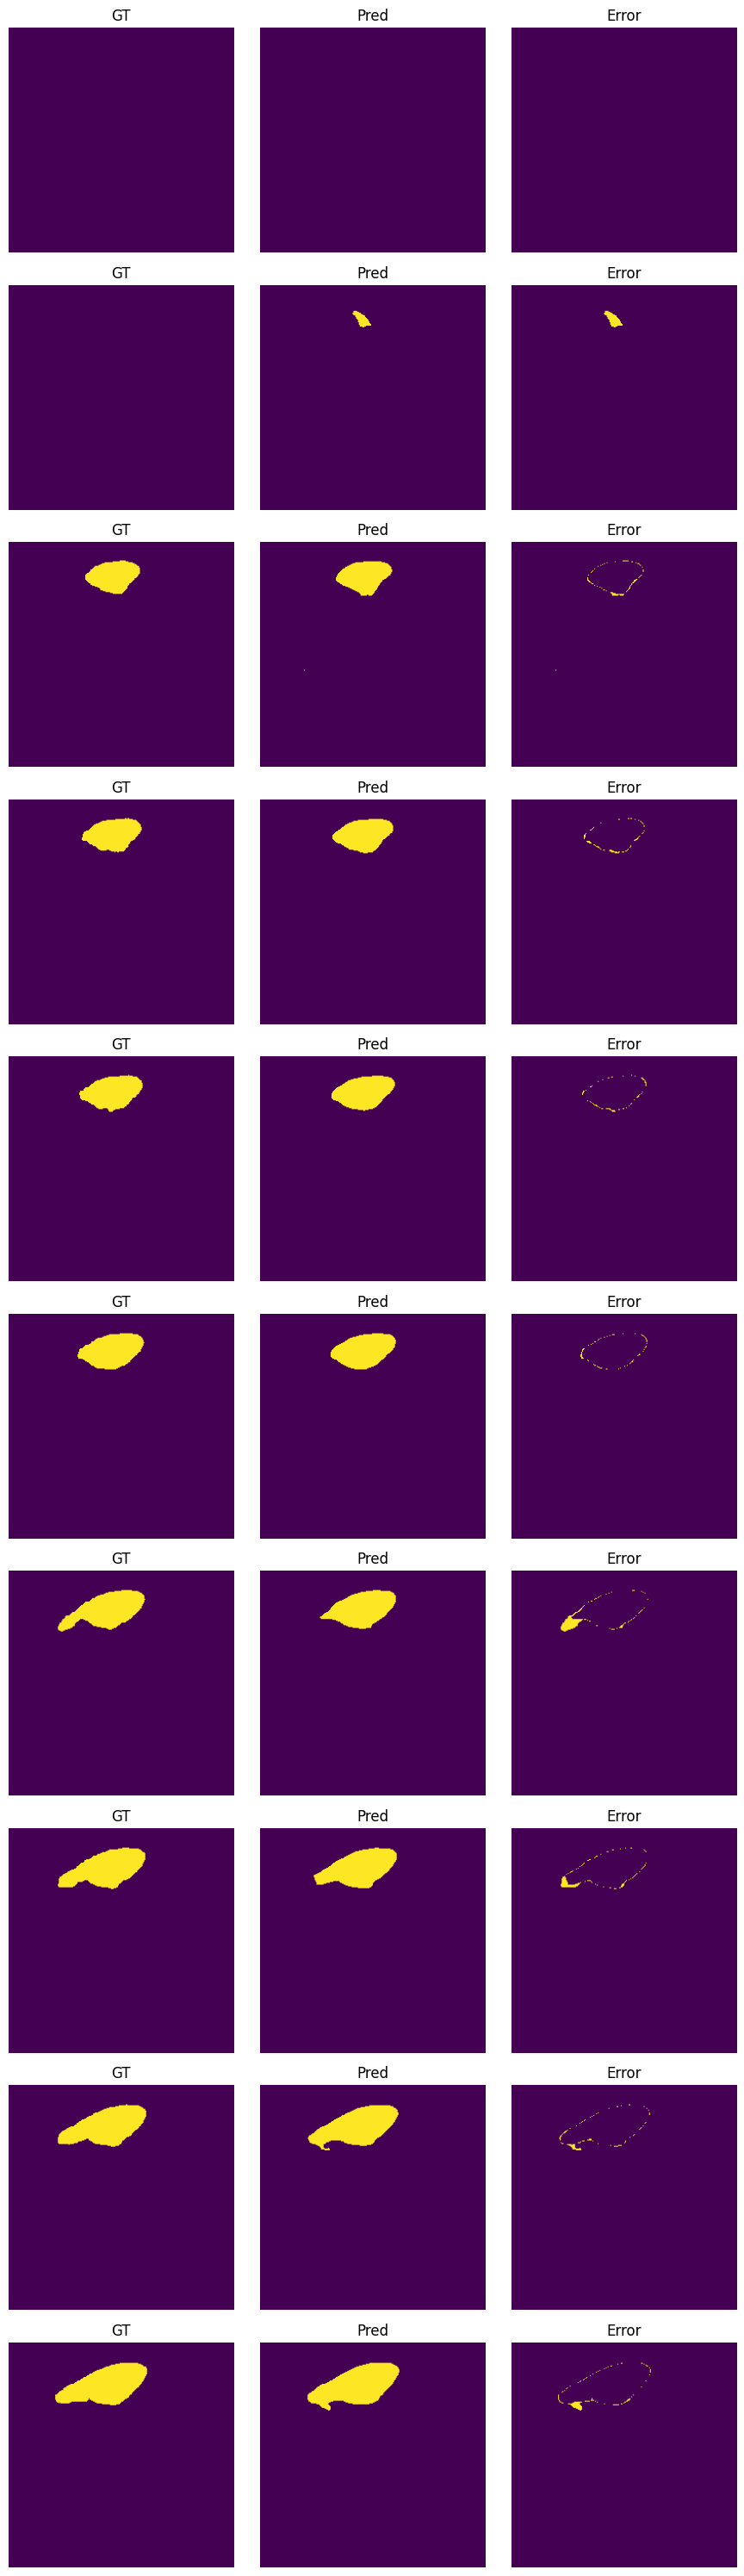

: 

: 

In [ ]:
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt

def dice_loss(pred, target, num_classes=3, smooth=1e-6):
    if pred.dim() == 3:
        pred = F.one_hot(pred.long(), num_classes).permute(0, 3, 1, 2).float()
    else:
        pred = F.softmax(pred, dim=1)
    target = F.one_hot(target.long(), num_classes).permute(0, 3, 1, 2).float()
    intersection = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()

def compute_dice_loss_batch(pred, batch, num_classes=3):
    gt = batch['semantic'].to(pred.device)
    return dice_loss(pred, gt, num_classes=num_classes).item()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_dir = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/checkpoints_only_sem_head_fa_atlas"
efficientps = EffificientPS(cfg)
efficientps.load_state_dict(torch.load(f"{ckpt_dir}/efficientps_epoch98.pth", map_location=device))
efficientps.to(device)
efficientps.eval()

K = 10
samples = []

with torch.no_grad():
    for batch in valid_loader:
        batch['image'] = batch['image'].to(device)
        batch['semantic'] = batch['semantic'].to(device)

        preds, _ = efficientps.shared_step(batch)
        panoptic = panoptic_segmentation(cfg, preds, device)   # (B,H,W)

        for i in range(panoptic.size(0)):
            if len(samples) == K:
                break
            gt  = batch['semantic'][i].cpu().numpy()
            pr  = panoptic[i].cpu().numpy()
            err = (gt != pr).astype(float)
            samples.append((gt, pr, err))
        if len(samples) == K:
            break
# import random
# samples = random.sample(samples, K)

fig, axes = plt.subplots(K, 3, figsize=(9, 3*K))
for r, (gt, pr, err) in enumerate(samples):
    axes[r, 0].imshow(gt);  axes[r, 0].set_title("GT");      axes[r, 0].axis("off")
    axes[r, 1].imshow(pr);  axes[r, 1].set_title("Pred");    axes[r, 1].axis("off")
    axes[r, 2].imshow(err); axes[r, 2].set_title("Error");   axes[r, 2].axis("off")
plt.tight_layout(); plt.show()


In [ ]:

import numpy as np
from medpy import metric
from scipy.ndimage import zoom, distance_transform_edt
import torch.nn as nn
import SimpleITK as sitk
from tqdm import tqdm
from medpy.filter.binary import binary_edge_detection

def compute_nsd(pred, gt, tolerance_mm=1.0, spacing=(1.0, 1.0, 1.0)):
    """
    Compute Normalized Surface Dice (NSD) between binary prediction and ground truth masks.
    """
    pred = pred.astype(np.bool_)
    gt = gt.astype(np.bool_)

    if not pred.any() and not gt.any():
        return 1.0
    if pred.sum() == 0 or gt.sum() == 0:
        return 0.0

    pred_surface = binary_edge_detection(pred)
    gt_surface = binary_edge_detection(gt)

    dt_gt = distance_transform_edt(~gt, sampling=spacing)
    dt_pred = distance_transform_edt(~pred, sampling=spacing)

    pred_to_gt = dt_gt[pred_surface]
    gt_to_pred = dt_pred[gt_surface]

    pred_close = np.sum(pred_to_gt <= tolerance_mm)
    gt_close = np.sum(gt_to_pred <= tolerance_mm)
    nsd = (pred_close + gt_close) / (pred_surface.sum() + gt_surface.sum() + 1e-8)

    return nsd

ImportError: cannot import name 'binary_edge_detection' from 'medpy.filter.binary' (/home/miglab/miniconda3/lib/python3.12/site-packages/medpy/filter/binary.py)

: 

: 

In [ ]:
from medpy import metric
def calculate_metric_percase(pred, gt, spacing=(1.0, 1.0, 1.0), tolerance_mm=1.0):
    pred[pred > 0] = 1
    gt[gt > 0] = 1
    if pred.sum() > 0 and gt.sum() > 0:
        dice = metric.binary.dc(pred, gt)
        hd95 = metric.binary.hd95(pred, gt)
        nsd = compute_nsd(pred, gt, tolerance_mm=tolerance_mm, spacing=spacing)
        return dice, hd95, nsd
    elif pred.sum() > 0 and gt.sum() == 0:
        return 1, 0, 0
    else:
        return 0, 0, 0




: 

: 

In [ ]:

# class DiceLoss(nn.Module):
#     def __init__(self, n_classes, ignore_index=-1):
#         super(DiceLoss, self).__init__()
#         self.n_classes = n_classes
#         self.ignore_index = ignore_index

#     def _one_hot_encoder(self, input_tensor):
#         tensor_list = []
#         for i in range(self.n_classes):
#             temp_prob = (input_tensor == i) & (input_tensor != self.ignore_index)
#             tensor_list.append(temp_prob.unsqueeze(1))
#         output_tensor = torch.cat(tensor_list, dim=1)
#         return output_tensor.float()

#     def _dice_loss(self, score, target):
#         target = target.float()
#         smooth = 1e-5
#         intersect = torch.sum(score * target)
#         y_sum = torch.sum(target * target)
#         z_sum = torch.sum(score * score)
#         loss = (2 * intersect + smooth) / (z_sum + y_sum + smooth)
#         loss = 1 - loss
#         return loss

#     def forward(self, inputs, target, weight=None, softmax=False):
#         if softmax:
#             inputs = torch.softmax(inputs, dim=1)
        
#         mask = (target != self.ignore_index).float()
#         target = self._one_hot_encoder(target)
        
#         if weight is None:
#             weight = [1] * self.n_classes
        
#         assert inputs.size() == target.size(), 'predict {} & target {} shape do not match'.format(inputs.size(), target.size())
        
#         loss = 0.0
#         for i in range(0, self.n_classes):
#             dice = self._dice_loss(inputs[:, i] * mask, target[:, i])
#             loss += dice * weight[i]
#         return loss / self.n_classes



: 

: 

In [ ]:
# for batch in valid_loader:
#     # Move data to GPU
#     batch['image'] = batch['image'].to(device)
#     print(batch['semantic'])
#     print(np.unique(batch['semantic']))

#     print(batch['image'].shape)
    # break

: 

: 

In [ ]:
print(cfg.CHECKPOINT_PATH)

None


: 

: 

In [ ]:
import torch

from detectron2.structures import Instances

# Load Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
efficientps1 = EffificientPS(cfg)  # Adjust if needed

print("Before Loading Weights")
# print(torch.mean(efficientps1.instance_head.roi_heads.mask_head.last_conv.weight).item())

checkpoint_path = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/checkpoints_only_sem_head_fa_atlas/efficientps_epoch79.pth"  # Change this to your model path# Replace with your actual saved epoch file
efficientps1.load_state_dict(torch.load(checkpoint_path, map_location="cuda"))
efficientps1.to("cuda")
efficientps1.eval()
# total_params = sum(p.numel() for p in efficientps1.parameters() if p.requires_grad)
# print(f"Total Trainable Parameters: {total_params:,}")

for name, param in efficientps1.named_parameters():
    print(name, torch.mean(param).item())  # Print mean weight values
print("\nAfter Loading Weights")
# print(torch.mean(efficientps1.instance_head.roi_heads.mask_head.last_conv.weight).item())


Before Loading Weights


/tmp/ipykernel_132542/2086201988.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  efficientps1.load_state_dict(torch.load(checkpoint_path, map_location="cuda"))


backbone._conv_stem.weight 0.0023117447271943092
backbone._bn0.weight 0.6922938823699951
backbone._bn0.bias 0.007873546332120895
backbone._blocks.0._depthwise_conv.weight -0.004468931350857019
backbone._blocks.0._bn1.weight 0.9823341965675354
backbone._blocks.0._bn1.bias 0.0034917083103209734
backbone._blocks.0._project_conv.weight -0.0010314284591004252
backbone._blocks.0._bn2.weight 1.0210041999816895
backbone._blocks.0._bn2.bias 0.023045862093567848
backbone._blocks.1._depthwise_conv.weight -0.005717259366065264
backbone._blocks.1._bn1.weight 0.9741185903549194
backbone._blocks.1._bn1.bias 0.005015274044126272
backbone._blocks.1._project_conv.weight 0.003461875021457672
backbone._blocks.1._bn2.weight 0.9643415212631226
backbone._blocks.1._bn2.bias 0.006583500653505325
backbone._blocks.2._depthwise_conv.weight 0.02609391137957573
backbone._blocks.2._bn1.weight 0.970659077167511
backbone._blocks.2._bn1.bias 0.0047233677469193935
backbone._blocks.2._project_conv.weight -0.0032158191315

: 

: 

In [ ]:
# import torch
# import torch.nn.functional as F
# import numpy as np
# import os
# import cv2
# from tqdm import tqdm

# def dice_coeff(y_true, y_pred, smooth=1e-6):
#     y_true_f = y_true.view(-1)
#     y_pred_f = y_pred.view(-1)
#     intersection = (y_true_f * y_pred_f).sum()
#     return (2. * intersection + smooth) / (y_true_f.sum() + y_pred_f.sum() + smooth)

# def resize_and_place_mask(mask_tensor, box, output_size=(256, 256)):
#     x1, y1, x2, y2 = map(int, box)
#     h, w = y2 - y1, x2 - x1

#     # Ensure mask_tensor is [1, 1, H, W]
#     if mask_tensor.dim() == 2:
#         mask_tensor = mask_tensor.unsqueeze(0).unsqueeze(0)
#     elif mask_tensor.dim() == 3:
#         mask_tensor = mask_tensor.unsqueeze(0)
#     mask_tensor = mask_tensor.to(torch.float32)

#     # Only interpolate if size is valid (non-zero)
#     if h > 0 and w > 0:
#         resized = F.interpolate(mask_tensor, size=(h, w), mode='bilinear', align_corners=False)
#         resized = resized.squeeze().detach().cpu().numpy()
#         binary_mask = (resized > 0.5).astype(np.uint8) * 255
#     else:
#         binary_mask = np.zeros((h, w), dtype=np.uint8)

#     # Place the resized mask at the right location
#     placed_mask = np.zeros(output_size, dtype=np.uint8)
#     if y2 > y1 and x2 > x1:
#         placed_mask[y1:y2, x1:x2] = binary_mask
#     return placed_mask

# # Paths
# gt_folder = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Liver_dataset/gtFine/val"

# # Accumulators
# dice_semantic_total = 0.0
# dice_instance_total = 0.0
# count = 0

# # Put model in eval mode
# efficientps1.eval()
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# with torch.no_grad():
#     for batch in tqdm(valid_loader):
#         # raise Exception
#         # Move data to GPU
#         batch['image'] = batch['image'].to(device)
#         batch['semantic'] = batch['semantic'].to(device)
#         for i in range(len(batch['instance'])):
#             batch['instance'][i].gt_masks = batch['instance'][i].gt_masks.to(device)
#             batch['instance'][i].gt_classes = batch['instance'][i].gt_classes.to(device)
#             batch['instance'][i].gt_boxes = batch['instance'][i].gt_boxes.to(device)

#         # Forward pass
#         outputs, _ = efficientps1.shared_step(batch)
        
#         image_ids = batch['image_id']
#         semantics = outputs['semantic']
#         instances_batch = outputs['instance']
#         # print(instances_batch)
#         # raise Exception
#         for i in range(len(image_ids)):
#             # === Semantic Mask ===
#             semantic_logits = semantics[i]  # [C, H, W]
#             # print(semantic_logits.shape)
#             # print(semantic_logits)
#             # print(semantic_logits.min(), semantic_logits.max())
#             # print(semantic_logits[:, -1, -1])
#             semantic_mask = torch.argmax(semantic_logits, dim=0)
#             # print(semantic_mask)
            
#             semantic_binary = torch.where(semantic_mask == 1, 255, 0).to(torch.uint8).detach().cpu().numpy()
            
#             # === Instance Mask ===
#             full_instance_mask = np.zeros((256, 256), dtype=np.uint8)
#             instances = instances_batch[i] if instances_batch is not None and instances_batch[i] is not None else None

#             if instances is not None:
#                 pred_boxes = instances.get_fields()['pred_boxes'].tensor.detach().cpu().numpy()
#                 pred_masks = instances.get_fields()['pred_masks'].to(device)

#                 for j in range(len(pred_masks)):
#                     mask_tensor = pred_masks[j]
#                     box = pred_boxes[j]
#                     placed = resize_and_place_mask(mask_tensor, box)
#                     full_instance_mask = np.maximum(full_instance_mask, placed)

#             # === Ground Truth ===
#             # gt_path = os.path.join(gt_folder, f"{image_ids[i]}.png")
#             # gt_mask = cv2.imread(gt_path, cv2.IMREAD_UNCHANGED)
#             # if gt_mask is None:
#             #     print(f"Missing GT for {image_ids[i]}")
#             #     continue
                        
#             # gt_binary = np.where(gt_mask == 1, 0, 255).astype(np.uint8)

#             gt_mask = batch['semantic'][i].detach().cpu().numpy()
#             gt_binary = np.where(gt_mask==0, 0, 255).astype(np.uint8)
            
#             # Convert to tensors (on CUDA)
#             gt_tensor = torch.tensor(gt_binary / 255.0, dtype=torch.float32, device=device) 
#             semantic_tensor = torch.tensor(semantic_binary / 255.0, dtype=torch.float32, device=device)
#             instance_tensor = torch.tensor(full_instance_mask / 255.0, dtype=torch.float32, device=device)

#             dice_sem = dice_coeff(gt_tensor, semantic_tensor).item()
#             dice_ins = dice_coeff(gt_tensor, instance_tensor).item()

#             dice_semantic_total += dice_sem
#             dice_instance_total += dice_ins
#             count += 1


# # === Final Results ===
# avg_dice_sem = dice_semantic_total / count if count else 0
# avg_dice_ins = dice_instance_total / count if count else 0

# print(f"\n✅ Average Dice Coefficient (Semantic): {avg_dice_sem:.4f}")
# print(f"✅ Average Dice Coefficient (Instance): {avg_dice_ins:.4f}")


100%|██████████| 550/550 [00:58<00:00,  9.37it/s]


✅ Average Dice Coefficient (Semantic): 0.9353
✅ Average Dice Coefficient (Instance): 0.8986


: 

: 

In [ ]:
from PIL import Image
import torchvision.transforms as transforms


# ssmb_image_id1 = "0001_32_"
# ssmb_image_id2 = "_0061"
# ssmb_image_id1 = "0001_32_"
# ssmb_image_id2 = "_0064"
# ssmb_image_id1 = "0095_31_"
# ssmb_image_id2 = "_0016"
# ssmb_image_id1 = "0005_4_"
# ssmb_image_id2 = "_0046"

# ssmb_image_id1 = "0001_31_"
# ssmb_image_id2 = "_0036"

# Load and preprocess a test image
image_path = f"/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Atlas_dataset/leftImg8bit/val/im0_24.png"

# Load image as grayscale explicitly
image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)  # shape: (H, W)

# Expand dimensions to add channel
image = np.expand_dims(image, axis=-1)  # shape: (H, W, 1)



transform = A.Compose([
    A.Resize(height=256, width=256),
    A.Normalize(mean=cfg.TRANSFORM.NORMALIZE.MEAN, std=cfg.TRANSFORM.NORMALIZE.STD),
])
transformed = transform(image=image)
image_tensor = torch.tensor(transformed["image"]).permute(2, 0, 1).float().unsqueeze(0).to("cuda")  # (1, 1, 256, 256)

  # Add batch dimension
print("Input tensor shape:", image_tensor.shape)
print("Input tensor dtype:", image_tensor.dtype)
# Debugging shape
print("Input Shape:", image_tensor.shape)  # Should be (1, 3, 256, 256)

# Wrap in dictionary for model compatibility
inputs = {"image": image_tensor}  # Remove batch dimension
print(torch.isnan(image_tensor).any(), torch.isinf(image_tensor).any())
# raise Exception

# Run inference
with torch.no_grad():
    outputs, _ = efficientps1.shared_step(inputs)  # Pass dictionary instead of tensor
    # predictions, loss = efficientps.shared_step(batch)
    # outputs = panoptic_segmentation(cfg, predictions, device)

# Debugging outputs
print(outputs)
# print(los)


Input tensor shape: torch.Size([1, 1, 256, 256])
Input tensor dtype: torch.float32
Input Shape: torch.Size([1, 1, 256, 256])
tensor(False, device='cuda:0') tensor(False, device='cuda:0')
{'semantic': tensor([[[[9.9999e-01, 9.9999e-01, 1.0000e+00,  ..., 1.0000e+00,
           1.0000e+00, 1.0000e+00],
          [9.9999e-01, 9.9999e-01, 1.0000e+00,  ..., 1.0000e+00,
           1.0000e+00, 1.0000e+00],
          [1.0000e+00, 1.0000e+00, 1.0000e+00,  ..., 1.0000e+00,
           1.0000e+00, 1.0000e+00],
          ...,
          [1.0000e+00, 1.0000e+00, 1.0000e+00,  ..., 1.0000e+00,
           1.0000e+00, 1.0000e+00],
          [1.0000e+00, 1.0000e+00, 1.0000e+00,  ..., 1.0000e+00,
           1.0000e+00, 1.0000e+00],
          [1.0000e+00, 1.0000e+00, 1.0000e+00,  ..., 1.0000e+00,
           1.0000e+00, 1.0000e+00]],

         [[9.3491e-07, 9.3491e-07, 7.1752e-07,  ..., 3.2575e-11,
           2.9864e-11, 2.9864e-11],
          [9.3491e-07, 9.3491e-07, 7.1752e-07,  ..., 3.2575e-11,
           

: 

: 

In [ ]:
semantic_logits = torch.argmax(outputs['semantic'], dim=1)
print(semantic_logits.unique())

tensor([0, 1, 2], device='cuda:0')


: 

: 

torch.Size([1, 3, 256, 256])
tensor([[[[9.9999e-01, 9.9999e-01, 1.0000e+00,  ..., 1.0000e+00,
           1.0000e+00, 1.0000e+00],
          [9.9999e-01, 9.9999e-01, 1.0000e+00,  ..., 1.0000e+00,
           1.0000e+00, 1.0000e+00],
          [1.0000e+00, 1.0000e+00, 1.0000e+00,  ..., 1.0000e+00,
           1.0000e+00, 1.0000e+00],
          ...,
          [1.0000e+00, 1.0000e+00, 1.0000e+00,  ..., 1.0000e+00,
           1.0000e+00, 1.0000e+00],
          [1.0000e+00, 1.0000e+00, 1.0000e+00,  ..., 1.0000e+00,
           1.0000e+00, 1.0000e+00],
          [1.0000e+00, 1.0000e+00, 1.0000e+00,  ..., 1.0000e+00,
           1.0000e+00, 1.0000e+00]],

         [[9.3491e-07, 9.3491e-07, 7.1752e-07,  ..., 3.2575e-11,
           2.9864e-11, 2.9864e-11],
          [9.3491e-07, 9.3491e-07, 7.1752e-07,  ..., 3.2575e-11,
           2.9864e-11, 2.9864e-11],
          [7.6380e-07, 7.6380e-07, 5.9387e-07,  ..., 4.1991e-11,
           4.0343e-11, 4.0343e-11],
          ...,
          [1.6146e-06, 1.6146e

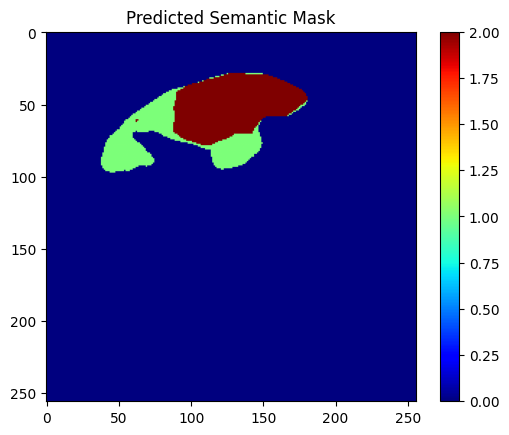

: 

: 

In [ ]:
import torch
import matplotlib.pyplot as plt

# Assuming `outputs['semantic']` is of shape [1, num_classes, 256, 256]
print(outputs['semantic'].shape)
print(outputs['semantic'])

semantic_logits = outputs['semantic'].squeeze(0)  # Remove batch dimension
print(semantic_logits.min().item())
print(semantic_logits.max().item())
semantic_mask = torch.argmax(semantic_logits, dim=0).cpu().numpy()  # Convert to class indices
print(np.unique(semantic_mask))

plt.imshow(semantic_mask, cmap="jet")
plt.colorbar()
plt.title("Predicted Semantic Mask")
plt.show()


In [ ]:
# import os
# import numpy as np
# from PIL import Image
# from tqdm import tqdm

# # 🔁 Set your image folder path here
# folder_path = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Liver_dataset/gtFine/val"

# # Initialize counters
# num_liver_images = 0
# num_no_liver_images = 0
# total_images = 0

# # List all image files (assuming common image formats)
# image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.bmp'))]

# # Iterate through images
# for img_file in tqdm(image_files):
#     img_path = os.path.join(folder_path, img_file)
#     image = Image.open(img_path)
#     image_np = np.array(image)

#     if 2001 in image_np:
#         num_liver_images += 1
#     else:
#         num_no_liver_images += 1

#     total_images += 1

# # ✅ Final Output
# print(f"\n📊 Total Images: {total_images}")
# print(f"🧠 Images with Liver (value 2001): {num_liver_images}")
# print(f"⚪ Images with No Liver (only value 1): {num_no_liver_images}")


: 

: 

In [ ]:
# import torch.nn.functional as F

# # Extract the predicted mask (shape: [1, 1, 28, 28])
# pred_mask = outputs['instance'][0].get_fields()['pred_masks']  # Shape (1, 1, 28, 28)

# # Resize the mask to 256x256
# upsampled_mask = F.interpolate(pred_mask, size=(256, 256), mode="bilinear", align_corners=False)
# upsampled_mask = upsampled_mask.squeeze(1).detach().cpu().numpy()  # Remove batch dims

# print(upsampled_mask.shape)
# upsampled_mask1 = upsampled_mask[0]
# upsampled_mask2 = upsampled_mask[1]
# # Convert to binary mask (threshold at 0.5)
# binary_mask = (upsampled_mask2 > 0.5).astype("uint8")

# # Display the final upsampled mask
# plt.figure(figsize=(5, 5))
# plt.imshow(binary_mask, cmap="gray")
# plt.title("Upsampled Instance Mask (256×256)")
# plt.axis("off")
# plt.show()


: 

: 

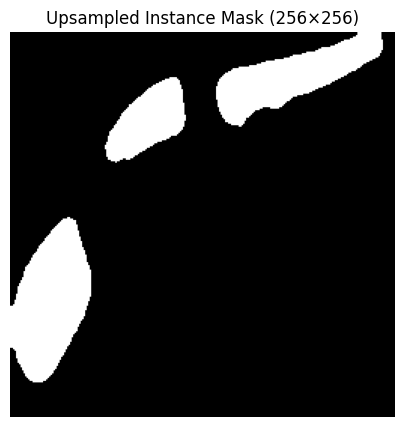

: 

: 

In [ ]:
import torch.nn.functional as F

# Extract the predicted mask (shape: [1, 1, 28, 28])
pred_mask = outputs['instance'][0].get_fields()['pred_masks']  # Shape (1, 1, 28, 28)

# Resize the mask to 256x256
upsampled_mask = F.interpolate(pred_mask, size=(256, 256), mode="bilinear", align_corners=False)
upsampled_mask = upsampled_mask.squeeze(0).squeeze(0).detach().cpu().numpy()  # Remove batch dims

# Convert to binary mask (threshold at 0.5)
binary_mask = (upsampled_mask > 0.5).astype("uint8")

# Display the final upsampled mask
plt.figure(figsize=(5, 5))
plt.imshow(binary_mask, cmap="gray")
plt.title("Upsampled Instance Mask (256×256)")
plt.axis("off")
plt.show()


In [ ]:
# import numpy as np
# import torch.nn.functional as F
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches

# # Extract predicted boxes and masks
# instances = outputs['instance'][0]
# pred_boxes = instances.get_fields()['pred_boxes'].tensor.cpu().numpy()  # Shape: (N, 4)
# pred_masks = instances.get_fields()['pred_masks']  # Shape: (N, 1, 28, 28)

# print(instances.get_fields())
# # Create figure with two subplots for each instance
# fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# for i in range(2):  # Assuming there are exactly 2 instances
#     x1, y1, x2, y2 = map(int, pred_boxes[i])

#     # Resize the mask to bounding box size
#     resized_mask = F.interpolate(pred_masks[i].unsqueeze(0), size=(y2 - y1, x2 - x1), mode="bilinear", align_corners=False)
#     resized_mask = resized_mask.squeeze().detach().cpu().numpy()

#     binary_mask = (resized_mask > 0.5).astype(np.uint8)

#     # Place the resized mask in a 256x256 canvas
#     mask_canvas = np.zeros((256, 256), dtype=np.uint8)
#     mask_canvas[y1:y2, x1:x2] = binary_mask * 255

#     # Plot on respective subplot
#     axes[i].imshow(mask_canvas, cmap="gray")
#     axes[i].set_title(f"Instance {i + 1} with Box")
#     axes[i].axis("off")

#     # Draw bounding box
#     rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='red', facecolor='none')
#     axes[i].add_patch(rect)

# plt.tight_layout()
# plt.show()


: 

: 

In [ ]:

# import numpy as np
# import torch.nn.functional as F
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches

# # Extract predicted boxes and masks
# instances = outputs['instance'][0]
# pred_boxes = instances.get_fields()['pred_boxes'].tensor.cpu().numpy()  # Shape: (N, 4)
# pred_masks = instances.get_fields()['pred_masks']  # Shape: (N, 1, 28, 28)

# # Initialize a blank 256x256 mask
# full_mask = np.zeros((256, 256), dtype=np.uint8)

# # Create the figure and axis for plotting
# fig, ax = plt.subplots(figsize=(6, 6))
# ax.set_title("Final Mask with Bounding Boxes (256×256)")
# ax.axis("off")

# # Plot mask and draw bounding boxes
# for i in range(pred_masks.shape[0]):  
#     x1, y1, x2, y2 = map(int, pred_boxes[i])

#     # Resize mask to bounding box size
#     resized_mask = F.interpolate(pred_masks[i].unsqueeze(0), size=(y2 - y1, x2 - x1), mode="bilinear", align_corners=False)
#     resized_mask = resized_mask.squeeze().detach().cpu().numpy()

#     binary_mask = (resized_mask > 0.5).astype(np.uint8)
#     full_mask[y1:y2, x1:x2] = np.maximum(full_mask[y1:y2, x1:x2], binary_mask * 255)

#     # Draw bounding box
#     rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='red', facecolor='none')
#     ax.add_patch(rect)

# # Show final mask with boxes
# ax.imshow(full_mask, cmap="gray")
# plt.show()



: 

: 

In [ ]:
panoptic_result = panoptic_segmentation(cfg, outputs, device)

print(np.unique(panoptic_result.cpu().numpy()))

print(panoptic_result.shape)

tensor(1, device='cuda:0')
(tensor([], device='cuda:0', dtype=torch.int64), tensor([], device='cuda:0', dtype=torch.int64))
2


AttributeError: AREA_THRESH

: 

: 

/tmp/ipykernel_1238074/162249601.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', num_ids)  # You can change colormap here if needed


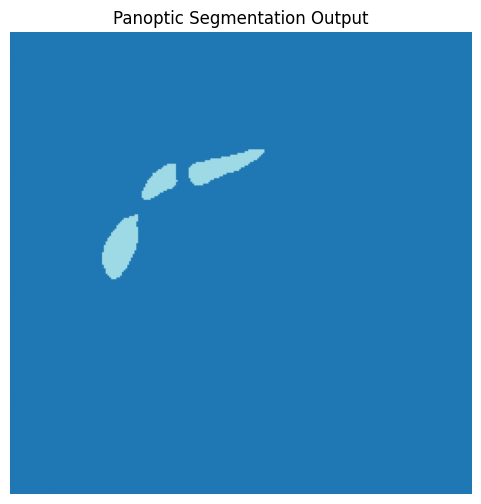

: 

: 

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Assuming panoptic_result is a PyTorch tensor of shape [1, 256, 256]
panoptic_np = panoptic_result.squeeze(0).cpu().numpy()  # shape [256, 256]

# Get unique IDs
unique_ids = np.unique(panoptic_np)

# Create a color map with a unique color for each ID
num_ids = len(unique_ids)
colors = plt.cm.get_cmap('tab20', num_ids)  # You can change colormap here if needed
id_to_color = {uid: colors(i)[:3] for i, uid in enumerate(unique_ids)}  # RGB colors

# Create RGB image for visualization
h, w = panoptic_np.shape
color_image = np.zeros((h, w, 3), dtype=np.float32)

for uid, color in id_to_color.items():
    color_image[panoptic_np == uid] = color

# Plot
plt.figure(figsize=(6, 6))
plt.imshow(color_image)
plt.title("Panoptic Segmentation Output")
plt.axis('off')
plt.show()


[   1 2000]


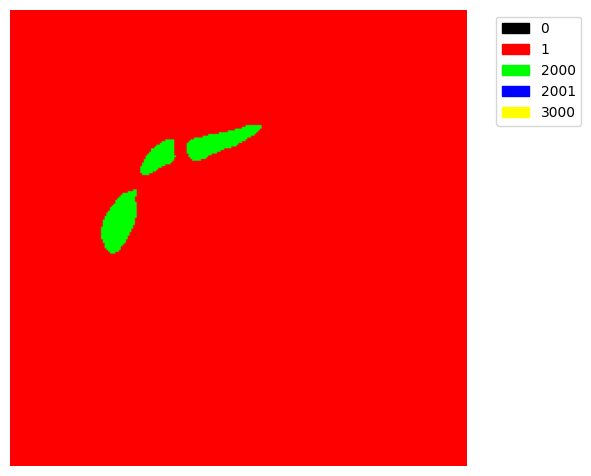

(256, 256)
[  0 255]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


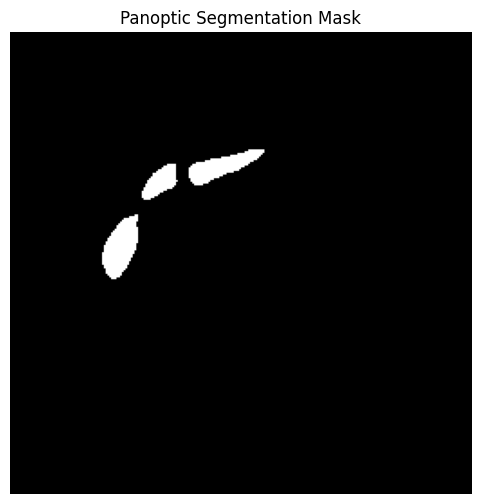

: 

: 

In [ ]:


print(np.unique(panoptic_result.cpu().numpy()))

panoptic_np = panoptic_result.squeeze(0).cpu().numpy()  # Shape: (256, 256)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Sample input array (your actual array will go here)
arr = panoptic_np

# Define unique values and assign custom colors
value_to_color = {
    0: (0, 0, 0),        # black
    1: (1, 0, 0),        # red
    2000: (0, 1, 0),     # green
    2001: (0, 0, 1),     # blue
    3000: (1, 1, 0),     # yellow
}

# Create an RGB image (256x256x3)
color_image = np.zeros((arr.shape[0], arr.shape[1], 3), dtype=np.float32)

# Map each value to its color
for val, color in value_to_color.items():
    color_image[arr == val] = color

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(color_image)
plt.axis('off')

# Add legend
patches = [mpatches.Patch(color=color, label=str(val)) for val, color in value_to_color.items()]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



panoptic_result = np.where(panoptic_np == 1, 0, 255).astype(np.uint8)
print(panoptic_result.shape)
print(np.unique(panoptic_result))
print(panoptic_result)
import matplotlib.pyplot as plt

def visualize_mask(mask):
    plt.figure(figsize=(6, 6))
    plt.imshow(mask, cmap='gray')  # Convert to NumPy and display
    plt.axis('off')  # Hide axes
    plt.title("Panoptic Segmentation Mask")
    plt.show()

# Example Usage (assuming inter_preds is a PyTorch tensor)
visualize_mask(panoptic_result)


In [ ]:
# import torch
# from tqdm import tqdm

# # Ensure model is in eval mode and on correct device
# efficientps1.eval()
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# count_multiple_instances = 0  # Counter for images with >1 instance
# total_images = 0

# with torch.no_grad():
#     for batch in tqdm(valid_loader):
#         batch['image'] = batch['image'].to(device)
#         batch['semantic'] = batch['semantic'].to(device)
#         image_ids = batch['image_id']  # Get the image IDs

#         for i in range(len(batch['instance'])):
#             batch['instance'][i].gt_masks = batch['instance'][i].gt_masks.to(device)
#             batch['instance'][i].gt_classes = batch['instance'][i].gt_classes.to(device)
#             batch['instance'][i].gt_boxes = batch['instance'][i].gt_boxes.to(device)

#         outputs, _ = efficientps1.shared_step(batch)
#         instances_batch = outputs['instance']

#         if instances_batch is None or isinstance(instances_batch, dict):
#             continue

#         for i, instances in enumerate(instances_batch):
#             total_images += 1
#             if instances is not None:
#                 pred_boxes = instances.get_fields()['pred_boxes']
#                 if len(pred_boxes) > 1:
#                     count_multiple_instances += 1
#                     # print(f"\n🖼️ Image ID: {image_ids[i]}")
#                     # print(f"📦 Predicted Bounding Boxes (Count: {len(pred_boxes)}):\n{pred_boxes}")

# print(f"\n✅ Total Images in Validation Set: {total_images}")
# print(f"✅ Images with >1 Predicted Instance: {count_multiple_instances}")


  1%|          | 4/550 [00:02<04:32,  2.01it/s]


🖼️ Image ID: 0001_32_masks_0061
📦 Predicted Bounding Boxes (Count: 2):
Boxes(tensor([[ 57.0017,  62.5407, 165.2297, 119.7952],
        [ 85.8134,  61.4940, 163.0073,  88.4383]], device='cuda:0'))

🖼️ Image ID: 0001_32_masks_0064
📦 Predicted Bounding Boxes (Count: 2):
Boxes(tensor([[ 90.6127,  60.9088, 155.8807,  83.9112],
        [ 45.9783,  61.9801, 158.1419, 130.7492]], device='cuda:0'))


  1%|▏         | 8/550 [00:03<04:06,  2.20it/s]


🖼️ Image ID: 0002_7_masks_0016
📦 Predicted Bounding Boxes (Count: 2):
Boxes(tensor([[ 47.9593,  43.7475, 143.4117, 138.0618],
        [ 43.0702,  64.6692,  76.9006, 141.0937]], device='cuda:0'))


  3%|▎         | 18/550 [00:08<03:34,  2.48it/s]

...


🖼️ Image ID: 0095_31_masks_0043
📦 Predicted Bounding Boxes (Count: 2):
Boxes(tensor([[ 40.6818,  68.3630, 125.1653, 177.6342],
        [ 41.4027,  92.1352,  62.4722, 149.7643]], device='cuda:0'))


100%|██████████| 550/550 [03:52<00:00,  2.36it/s]


✅ Total Images in Validation Set: 4295
✅ Images with >1 Predicted Instance: 164


: 

: 

In [ ]:
# import matplotlib.pyplot as plt
# import torch.nn.functional as F
# import numpy as np
# import cv2

# # Extract instance predictions
# instances = outputs['instance'][0]
# pred_boxes = instances.get_fields()['pred_boxes'].tensor.cpu().numpy()  # Shape: (N, 4)
# pred_masks = instances.get_fields()['pred_masks']  # Shape: (N, 1, 28, 28)

# # Initialize full-size instance mask (256x256)
# full_mask = np.zeros((256, 256), dtype=np.uint8)

# # Just show the first instance (for example)
# i = 0
# x1, y1, x2, y2 = map(int, pred_boxes[i])  # Bounding box coordinates

# # Resize 28x28 mask to match the bounding box
# resized_mask = F.interpolate(pred_masks[i].unsqueeze(0), size=(y2 - y1, x2 - x1), mode="bilinear", align_corners=False)
# resized_mask = resized_mask.squeeze(0).squeeze(0).detach().cpu().numpy()

# # Convert to binary mask
# binary_mask = (resized_mask > 0.5).astype(np.uint8)

# # Paste into full-size image
# full_mask[y1:y2, x1:x2] = binary_mask * 255  # Liver = 255, background = 0

# # Ground truth
# ground_truth = cv2.imread(
#     f"/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Liver_dataset/output/cityscapes_panoptic_val/{ssmb_image_id1}masks{ssmb_image_id2}_panoptic.png",
#     cv2.IMREAD_UNCHANGED
# )

# # Semantic mask (make sure it's numpy)
# semantic_mask = semantic_mask.cpu().numpy() if torch.is_tensor(semantic_mask) else semantic_mask

# # Panoptic mask (convert to binary: liver = 255, background = 0)
# panoptic_np = panoptic_result.squeeze(0).cpu().numpy()  # Shape: (256, 256)
# panoptic_mask = np.where(panoptic_np == 1, 0, 255).astype(np.uint8)  # Liver = white (255), background = black (0)

# # Plot in a 2x2 grid
# fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# # Top row: Ground Truth and Semantic
# axes[0, 0].imshow(ground_truth, cmap='gray')
# axes[0, 0].set_title("Ground Truth Mask")
# axes[0, 0].axis("off")

# axes[0, 1].imshow(semantic_mask, cmap='jet')
# axes[0, 1].set_title("Predicted Semantic Mask")
# axes[0, 1].axis("off")

# # Bottom row: Instance and Panoptic
# axes[1, 0].imshow(full_mask, cmap='gray')
# axes[1, 0].set_title("Predicted Instance Mask")
# axes[1, 0].axis("off")

# axes[1, 1].imshow(panoptic_mask, cmap='gray')
# axes[1, 1].set_title("Predicted Panoptic Mask")
# axes[1, 1].axis("off")

# plt.tight_layout()
# plt.show()


: 

: 

In [ ]:
# ground_mask = np.all(ground_truth == [0, 0, 1], axis=-1)
# ground_mask = np.where(ground_mask==True, 0, 1)

# # print(type(ground_mask), type(semantic_mask))
# ground_mask = torch.tensor(ground_mask, dtype=torch.float32)
# semantic_mask = torch.tensor(semantic_mask, dtype=torch.float32)
# bin_mask = np.zeros((256, 256), dtype=np.uint8)
# bin_mask[y1:y2, x1:x2] = binary_mask  # Liver = 255, background = 0
# instance_masking = torch.tensor(bin_mask, dtype=torch.float32)
# pan_mask = np.where(panoptic_np == 1, 0, 1).astype(np.uint8)  # Liver = white (255), background = black (0)

# pan_mask = torch.tensor(pan_mask, dtype=torch.float32)

# print(np.unique(ground_mask))
# print(np.unique(semantic_mask))
# print(np.unique(instance_masking))
# print(np.unique(pan_mask))
# print(ground_mask.shape, semantic_mask.shape, instance_masking.shape, pan_mask.shape)
# print((1-dice_loss(ground_mask, semantic_mask)))
# print((1-dice_loss(ground_mask, instance_masking)))
# print((1-dice_loss(ground_mask, pan_mask)))

# plt.imshow(ground_mask, cmap='gray')
# plt.imshow(semantic_mask, cmap='gray')
# plt.imshow(instance_masking, cmap='gray')
# plt.imshow(pan_mask, cmap='gray')


: 

: 

In [ ]:
# import torch
# import torch.nn.functional as F
# import numpy as np
# import os
# import cv2
# from tqdm import tqdm

# def dice_coeff(y_true, y_pred, smooth=1e-6):
#     y_true_f = y_true.view(-1)
#     y_pred_f = y_pred.view(-1)
#     intersection = (y_true_f * y_pred_f).sum()
#     return (2. * intersection + smooth) / (y_true_f.sum() + y_pred_f.sum() + smooth)

# def resize_and_place_mask(mask_tensor, box, output_size=(256, 256)):
#     x1, y1, x2, y2 = map(int, box)
#     h, w = y2 - y1, x2 - x1

#     # Ensure mask_tensor is [1, 1, H, W]
#     if mask_tensor.dim() == 2:
#         mask_tensor = mask_tensor.unsqueeze(0).unsqueeze(0)
#     elif mask_tensor.dim() == 3:
#         mask_tensor = mask_tensor.unsqueeze(0)
#     mask_tensor = mask_tensor.to(torch.float32)

#     # Only interpolate if size is valid (non-zero)
#     if h > 0 and w > 0:
#         resized = F.interpolate(mask_tensor, size=(h, w), mode='bilinear', align_corners=False)
#         resized = resized.squeeze().detach().cpu().numpy()
#         binary_mask = (resized > 0.5).astype(np.uint8) * 255
#     else:
#         binary_mask = np.zeros((h, w), dtype=np.uint8)

#     # Place the resized mask at the right location
#     placed_mask = np.zeros(output_size, dtype=np.uint8)
#     if y2 > y1 and x2 > x1:
#         placed_mask[y1:y2, x1:x2] = binary_mask
#     return placed_mask

# # Paths
# gt_folder = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Liver_dataset/gtFine/val"

# # Accumulators
# dice_semantic_total = 0.0
# dice_instance_total = 0.0
# count = 0

# # Put model in eval mode
# efficientps.eval()
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# with torch.no_grad():
#     for batch in tqdm(valid_loader):
#         # Move data to GPU
#         batch['image'] = batch['image'].to(device)
#         batch['semantic'] = batch['semantic'].to(device)
#         for i in range(len(batch['instance'])):
#             batch['instance'][i].gt_masks = batch['instance'][i].gt_masks.to(device)
#             batch['instance'][i].gt_classes = batch['instance'][i].gt_classes.to(device)
#             batch['instance'][i].gt_boxes = batch['instance'][i].gt_boxes.to(device)

#         # Forward pass
#         outputs, _ = efficientps.shared_step(batch)
#         image_ids = batch['image_id']
#         semantics = outputs['semantic']
#         instances_batch = outputs['instance']

#         for i in range(len(image_ids)):
#             # === Semantic Mask ===
#             semantic_logits = semantics[i]  # [C, H, W]
#             semantic_mask = torch.argmax(semantic_logits, dim=0)
#             semantic_binary = torch.where(semantic_mask == 1, 255, 0).to(torch.uint8).detach().cpu().numpy()

#             # === Instance Mask ===
#             full_instance_mask = np.zeros((256, 256), dtype=np.uint8)
#             instances = instances_batch[i] if instances_batch is not None and instances_batch[i] is not None else None

#             if instances is not None:
#                 pred_boxes = instances.get_fields()['pred_boxes'].tensor.detach().cpu().numpy()
#                 pred_masks = instances.get_fields()['pred_masks'].to(device)

#                 for j in range(len(pred_masks)):
#                     mask_tensor = pred_masks[j]
#                     box = pred_boxes[j]
#                     placed = resize_and_place_mask(mask_tensor, box)
#                     full_instance_mask = np.maximum(full_instance_mask, placed)

#             # === Ground Truth ===
#             gt_path = os.path.join(gt_folder, f"{image_ids[i]}.png")
#             gt_mask = cv2.imread(gt_path, cv2.IMREAD_UNCHANGED)
#             if gt_mask is None:
#                 print(f"Missing GT for {image_ids[i]}")
#                 continue
#             gt_binary = np.where(gt_mask == 1, 0, 255).astype(np.uint8)

#             # Convert to tensors (on CUDA)
#             gt_tensor = torch.tensor(gt_binary / 255.0, dtype=torch.float32, device=device)
#             semantic_tensor = torch.tensor(semantic_binary / 255.0, dtype=torch.float32, device=device)
#             instance_tensor = torch.tensor(full_instance_mask / 255.0, dtype=torch.float32, device=device)

#             # Dice Coefficients
#             dice_sem = dice_coeff(gt_tensor, semantic_tensor).item()
#             dice_ins = dice_coeff(gt_tensor, instance_tensor).item()

#             dice_semantic_total += dice_sem
#             dice_instance_total += dice_ins
#             count += 1

# # === Final Results ===
# avg_dice_sem = dice_semantic_total / count if count else 0
# avg_dice_ins = dice_instance_total / count if count else 0

# print(f"\n✅ Average Dice Coefficient (Semantic): {avg_dice_sem:.4f}")
# print(f"✅ Average Dice Coefficient (Instance): {avg_dice_ins:.4f}")


: 

: 

In [ ]:
# import os
# import random
# import numpy as np
# import torch
# import cv2
# import matplotlib.pyplot as plt
# import albumentations as A
# from PIL import Image
# import torch.nn.functional as F
# from detectron2.structures import Instances

# # Set paths
# gt_dir = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Liver_dataset/output/cityscapes_panoptic_val"
# preds_dir = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Liver_dataset/leftImg8bit/val"

# # Load Model
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# efficientps1 = EffificientPS(cfg)
# checkpoint_path = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/efficientps_epoch36.pth"
# efficientps1.load_state_dict(torch.load(checkpoint_path, map_location=device))
# efficientps1.to(device)
# efficientps1.eval()

# # Preprocessing transform
# transform = A.Compose([
#     A.Resize(height=256, width=256),
#     A.Normalize(mean=cfg.TRANSFORM.NORMALIZE.MEAN, std=cfg.TRANSFORM.NORMALIZE.STD),
# ])

# # Sample 10 random images
# image_files = sorted([f for f in os.listdir(preds_dir) if f.endswith(".png")])
# sampled_files = random.sample(image_files, 10)
# print("Sampled files:", sampled_files)

# # Plot setup (2 columns: GT and Panoptic)
# fig, axes = plt.subplots(nrows=10, ncols=3, figsize=(10, 40))
# titles = ["Ground Truth", "Panoptic Prediction", "Error Map"]

# for row_idx, filename in enumerate(sampled_files):
#     # Image + GT mask paths
#     image_path = os.path.join(preds_dir, filename)
#     mask_name = filename.replace("images", "masks").replace(".png", "_panoptic.png")
#     mask_path = os.path.join(gt_dir, mask_name)

#     # Load and preprocess image
#     image = np.array(Image.open(image_path))
    
#     image = np.expand_dims(image, axis=-1)  # shape: (256, 256, 1)
#     transformed = transform(image=image)
#     image_transformed = transformed["image"]  # still shape (256, 256, 1)

#     # Convert to tensor: HWC → CHW → add batch dim
#     image_tensor = torch.tensor(image_transformed).permute(2, 0, 1).unsqueeze(0).float().to(device)  # shape: (1, 1, 256, 256)

#     # Prepare model input
#     inputs = {"image": image_tensor}
#     # Prediction
#     with torch.no_grad():
#         outputs, _ = efficientps1.shared_step(inputs)
#         panoptic_result = panoptic_segmentation(cfg, outputs, device)


#     # Panoptic mask
#     panoptic_np = panoptic_result.squeeze(0).cpu().numpy()  # shape (256, 256)
#     print(np.unique(panoptic_np))
#     # panoptic_bin = (panoptic_np == 1).astype(np.uint8) * 255  # liver=1 → 255
#     panoptic_bin = np.where(panoptic_np == 1, 0, 255).astype(np.uint8)

    
#     # Ground Truth mask
#     gt_mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
#     # gt_mask = cv2.resize(gt_mask, (256, 256), interpolation=cv2.INTER_NEAREST)
#     mask = np.all(gt_mask == [0, 0, 1], axis=-1)  # shape (H, W), boolean mask
#     gt_bin = np.where(mask, 0, 255).astype(np.uint8)



#     # print(np.unique(panoptic_bin))
#     error_map = np.abs(gt_bin.astype(np.int16) - panoptic_bin.astype(np.int16))
    
#     # Plot GT and Prediction side by side
#     masks_to_plot = [gt_bin, panoptic_bin, error_map]
#     for col_idx, mask in enumerate(masks_to_plot):
#         ax = axes[row_idx, col_idx]
#         ax.imshow(mask, cmap="gray")
#         ax.set_title(titles[col_idx] if row_idx == 0 else "")
#         ax.axis("off")

# plt.tight_layout()
# plt.savefig("panoptic_vs_gt_comparison.png", dpi=300, bbox_inches="tight")
# plt.show()


: 

: 

[   65536 13633280]
Unique Colors in the Image:
(0, 0, 1)
(0, 7, 208)


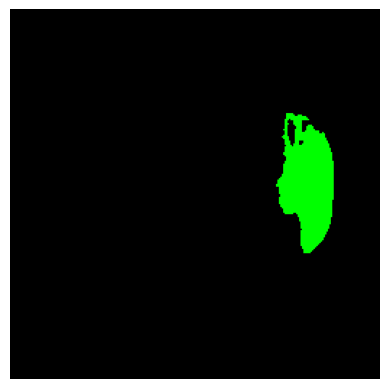

13633280


: 

: 

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def get_unique_colors(image_path):
    # Read the image in unchanged mode to preserve original values
    image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    
    if image is None:
        print("Error: Unable to read the image.")
        return
    print(np.unique(rgb2id(image)))
    # Convert image to a 2D array of colors (reshape and remove duplicates)
    unique_colors = np.unique(image.reshape(-1, image.shape[2]), axis=0)
    
    print("Unique Colors in the Image:")
    for color in unique_colors:
        print(tuple(color))

def display_colored_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if image is None:
        print("Error: Unable to read the image.")
        return
    
    # Define three distinct colors for visualization
    color_map = {
        (0, 0, 1): [0, 0, 0],       # Black for (0,0,1)
        (0, 0, 2): [255, 0, 0],     # Red for (0,0,2)
        (0, 7, 208): [0, 255, 0],
        (0, 7, 209): [0, 255, 0]   # Green for (0,7,208)
    }
    
    # Create an output image initialized to white
    output_image = np.ones_like(image) * 255
    
    for orig_color, new_color in color_map.items():
        mask = np.all(image == orig_color, axis=-1)
        output_image[mask] = new_color
    
    # Display the image using matplotlib (compatible with Ubuntu)
    plt.imshow(output_image)
    plt.axis('off')  # Hide axes
    plt.show()

# Example usage
image_path = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Liver_dataset/preds/0065_3_masks_0065_preds_panoptic.png"  # Replace with your image path
get_unique_colors(image_path)
display_colored_image(image_path)
print(rgb2id((0, 7, 208)))

: 

: 

In [ ]:
# import cv2
# import numpy as np

# def get_unique_colors(image_path):
#     # Read the image in unchanged mode to preserve original values
#     image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    
#     if image is None:
#         print("Error: Unable to read the image.")
#         return
    
#     # Convert image to a 2D array of colors (reshape and remove duplicates)
#     unique_colors = np.unique(image.reshape(-1, image.shape[2]), axis=0)
    
#     print("Unique Colors in the Image:")
#     for color in unique_colors:
#         print(tuple(color))

# def display_binary_image(image_path):
#     image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
#     if image is None:
#         print("Error: Unable to read the image.")
#         return
    
#     # Create a binary mask: 0,0,1 -> black, others -> white
#     mask = np.all(image == [0, 0, 1], axis=-1)
#     binary_image = np.where(mask[..., None], [0, 0, 0], [255, 255, 255]).astype(np.uint8)
    
#     # Display the image using matplotlib (compatible with Ubuntu)
#     import matplotlib.pyplot as plt
#     plt.imshow(binary_image)
#     plt.axis('off')  # Hide axes
#     plt.show()

# # Example usage
# # image_path = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Liver_dataset/preds/0001_32_masks_0027_preds_panoptic.png"  # Replace with your image path
# get_unique_colors(image_path)
# display_binary_image(image_path)

: 

: 

In [ ]:
# import torch
# import numpy as np
# import torch.nn.functional as F
# import cv2
# import matplotlib.pyplot as plt
# from detectron2.structures import Instances
# from PIL import Image
# import torchvision.transforms as transforms

# # Load Model
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# efficientps1 = EffificientPS(cfg)  # Ensure correct model initialization
# efficientps1.to(device)
# efficientps1.eval()

# # List of checkpoint paths (Modify this to match your file paths)
# checkpoint_paths = [
#     f"/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/efficientps_epoch{i}.pth" for i in range(1, 11)
# ]

# # Input image path (Replace this with the actual path)
# image_path = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Liver_dataset/leftImg8bit/val/0001_17_images_0020.png"

# # Load and preprocess image
# image = Image.open(image_path).convert("RGB")  # Ensure it's RGB

# # Apply transformations (match training setup)
# transform = A.Compose([
#     A.Resize(height=256, width=256),
#     A.Normalize(mean=cfg.TRANSFORM.NORMALIZE.MEAN, std=cfg.TRANSFORM.NORMALIZE.STD),
# ])
# transformed = transform(image=np.array(image))  # Albumentations needs numpy
# image_tensor = torch.tensor(transformed["image"]).permute(2, 0, 1).float().unsqueeze(0).to(device)

# # Load ground truth mask
# ground_truth_path = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Liver_dataset/output/cityscapes_panoptic_val/0001_17_masks_0020_panoptic.png"
# ground_truth = cv2.imread(ground_truth_path, cv2.IMREAD_GRAYSCALE)
# if ground_truth is None:
#     raise FileNotFoundError(f"Ground truth mask not found at {ground_truth_path}")
# ground_truth = cv2.resize(ground_truth, (256, 256))  # Ensure correct size

# # Create figure for all epochs
# fig, axes = plt.subplots(10, 3, figsize=(15, 50))

# for epoch, checkpoint in enumerate(checkpoint_paths):
#     # Load model weights
#     efficientps1.load_state_dict(torch.load(checkpoint, map_location=device))

#     # Inference
#     with torch.no_grad():
#         outputs, _ = efficientps1.shared_step({"image": image_tensor})

#     # Extract semantic mask
#     semantic_logits = outputs['semantic'].squeeze(0)  # Remove batch dimension
#     semantic_mask = torch.argmax(semantic_logits, dim=0).cpu().numpy()  # Convert to class indices

#     # Extract instance mask
#     instances = outputs['instance'][0]
#     pred_boxes = instances.get_fields()['pred_boxes'].tensor.cpu().numpy()  # Shape: (N, 4)
#     pred_masks = instances.get_fields()['pred_masks']  # Shape: (N, 1, 28, 28)

#     # Initialize instance mask
#     full_mask = np.zeros((256, 256), dtype=np.uint8)

#     for i in range(pred_masks.shape[0]):
#         x1, y1, x2, y2 = map(int, pred_boxes[i])  # Bounding box coordinates

#         # Resize the 28x28 mask to match the bounding box size
#         resized_mask = F.interpolate(pred_masks[i].unsqueeze(0), size=(y2 - y1, x2 - x1), mode="bilinear", align_corners=False)
#         resized_mask = resized_mask.squeeze(0).squeeze(0).detach().cpu().numpy()

#         # Convert to binary mask (threshold at 0.5)
#         binary_mask = (resized_mask > 0.5).astype(np.uint8)

#         # Paste into full image
#         full_mask[y1:y2, x1:x2] = binary_mask * 255  

#     # Plot results for this epoch
#     axes[epoch, 0].imshow(ground_truth, cmap='gray')
#     axes[epoch, 0].set_title(f"Epoch {epoch+1} - Ground Truth")
#     axes[epoch, 0].axis("off")

#     axes[epoch, 1].imshow(semantic_mask, cmap="jet")
#     axes[epoch, 1].set_title(f"Epoch {epoch+1} - Semantic Mask")
#     axes[epoch, 1].axis("off")

#     axes[epoch, 2].imshow(full_mask, cmap="gray")
#     axes[epoch, 2].set_title(f"Epoch {epoch+1} - Instance Mask")
#     axes[epoch, 2].axis("off")

# plt.tight_layout()
# plt.show()


: 

: 

In [ ]:
# import os
# import random
# import numpy as np
# import torch
# import cv2
# import matplotlib.pyplot as plt
# import albumentations as A
# from PIL import Image
# import torch.nn.functional as F
# from detectron2.structures import Instances

# # Set paths
# gt_dir = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Liver_dataset/output/cityscapes_panoptic_val"
# preds_dir = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/Liver_dataset/leftImg8bit/val"

# # Load Model
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# efficientps1 = EffificientPS(cfg)
# checkpoint_path = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical/efficientps_epoch36.pth"
# efficientps1.load_state_dict(torch.load(checkpoint_path, map_location=device))
# efficientps1.to(device)
# efficientps1.eval()

# # Preprocessing transform
# transform = A.Compose([
#     A.Resize(height=256, width=256),
#     A.Normalize(mean=cfg.TRANSFORM.NORMALIZE.MEAN, std=cfg.TRANSFORM.NORMALIZE.STD),
# ])

# # Sample 10 random images
# image_files = sorted([f for f in os.listdir(preds_dir) if f.endswith(".png")])
# sampled_files = random.sample(image_files, 10)
# print("Sampled files:", sampled_files)

# # Plot setup (2 columns: GT and Panoptic)
# fig, axes = plt.subplots(nrows=10, ncols=3, figsize=(10, 40))
# titles = ["Ground Truth", "Panoptic Prediction", "Error Map"]

# for row_idx, filename in enumerate(sampled_files):
#     # Image + GT mask paths
#     image_path = os.path.join(preds_dir, filename)
#     mask_name = filename.replace("images", "masks").replace(".png", "_panoptic.png")
#     mask_path = os.path.join(gt_dir, mask_name)

#     # Load and preprocess image
#     image = np.array(Image.open(image_path))
#     transformed = transform(image=image)
#     image_resized = transformed["image"]

#     input_tensor = torch.from_numpy(image_resized).permute(2, 0, 1).float().unsqueeze(0).to(device)
#     inputs = {"image": input_tensor}

#     # Prediction
#     with torch.no_grad():
#         outputs, _ = efficientps1.shared_step(inputs)
#         panoptic_result = panoptic_segmentation(cfg, outputs, device)


#     # Panoptic mask
#     panoptic_np = panoptic_result.squeeze(0).cpu().numpy()  # shape (256, 256)
#     print(np.unique(panoptic_np))
#     # panoptic_bin = (panoptic_np == 1).astype(np.uint8) * 255  # liver=1 → 255
#     panoptic_bin = np.where(panoptic_np == 1, 0, 255).astype(np.uint8)

    
#     # Ground Truth mask
#     gt_mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
#     # gt_mask = cv2.resize(gt_mask, (256, 256), interpolation=cv2.INTER_NEAREST)
#     mask = np.all(gt_mask == [0, 0, 1], axis=-1)  # shape (H, W), boolean mask
#     gt_bin = np.where(mask, 0, 255).astype(np.uint8)



#     # print(np.unique(panoptic_bin))
#     error_map = np.abs(gt_bin.astype(np.int16) - panoptic_bin.astype(np.int16))
    
#     # Plot GT and Prediction side by side
#     masks_to_plot = [gt_bin, panoptic_bin, error_map]
#     for col_idx, mask in enumerate(masks_to_plot):
#         ax = axes[row_idx, col_idx]
#         ax.imshow(mask, cmap="gray")
#         ax.set_title(titles[col_idx] if row_idx == 0 else "")
#         ax.axis("off")

# plt.tight_layout()
# plt.savefig("panoptic_vs_gt_comparison.png", dpi=300, bbox_inches="tight")
# plt.show()


: 

: 

In [ ]:
import os

def count_files(base_path):
    counts = {}
    total_counts = {}

    splits = ['train', 'test', 'valid']
    categories = ['images', 'labels', 'depth_masks_colored', 'descriptions']

    for split in splits:
        total_counts[split] = {}
        for category in categories:
            path = os.path.join(base_path, split, category)
            if os.path.isdir(path):
                class_counts = {}
                current_category_total = 0
                for class_name in os.listdir(path):
                    class_path = os.path.join(path, class_name)
                    if os.path.isdir(class_path):
                        num_files = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
                        class_counts[class_name] = num_files
                        current_category_total += num_files
                counts[f"{split}_{category}"] = class_counts
                total_counts[split][category] = current_category_total
            else:
                counts[f"{split}_{category}"] = "Path not found"
                total_counts[split][category] = "N/A"
    return counts, total_counts

# Replace 'your_dataset_base_path' with the actual path to your dataset
# For example: dataset_base_path = '/path/to/your/Dataset'
# Or if it's in the current directory: dataset_base_path = './Dataset'
dataset_base_path = '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/Desktop/Debris vision/FINAL_DATASET' # Update this path to your dataset's root directory

class_file_counts, total_category_counts = count_files(dataset_base_path)

print("Class-wise Counts:")
for key, value in class_file_counts.items():
    print(f"{key}: {value}")

print("\nTotal Counts per Category per Split:")
for split, categories in total_category_counts.items():
    print(f"Split: {split}")
    for category, total in categories.items():
        print(f"  {category}: {total}")

Class-wise Counts:
train_images: {'Miscellaneous': 139, 'Metal Containers': 700, 'Electronics': 75, 'Metal Rod': 10, 'Metal Can': 766, 'Metal Chain': 665, 'Masks and Gloves': 74, 'Mobile phones': 770, 'Metal': 321, 'Rubber Gloves': 637, 'Metal Shipwreck': 676, 'Plastic Bag': 1442, 'Plastic Wrappers': 1664, 'Glass Bottle': 737, 'Plastic Other': 945, 'Plastic Fishing Nets': 1364, 'Rubber Footwear': 774, 'Plastic Bottle': 1423, 'Sunglasses': 14, 'Fishing Rods': 669, 'Clothing Items': 699, 'Rubber Tires': 701}
train_labels: {'Miscellaneous': 139, 'Metal Containers': 700, 'Electronics': 75, 'Metal Rod': 10, 'Metal Can': 766, 'Metal Chain': 665, 'Masks and Gloves': 74, 'Mobile phones': 770, 'Metal': 321, 'Rubber Gloves': 637, 'Metal Shipwreck': 676, 'Plastic Bag': 1442, 'Plastic Wrappers': 1664, 'Glass Bottle': 737, 'Plastic Other': 945, 'Plastic Fishing Nets': 1364, 'Rubber Footwear': 774, 'Plastic Bottle': 1423, 'Sunglasses': 14, 'Fishing Rods': 669, 'Clothing Items': 699, 'Rubber Tires': 